### [Causal Discovery Using Bayesian Modeling](https://erdogant.medium.com/the-complete-starter-guide-for-causal-discovery-using-bayesian-modeling-8853eb860d02)

In [1]:
!pip install --quiet bnlearn d3blocks datazets distfit

In [2]:
import itertools

import numpy as np
import pandas as pd
import bnlearn as bn
import datazets as ds
import seaborn as sns
import matplotlib.pyplot as plt

from distfit import distfit
from lingam.utils import make_dot

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=8, suppress=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.8f}'.format)

plt.style.use("ggplot")

In [3]:
# Load sprinkler dataset
sprinkler_df = bn.import_example('sprinkler')

# Print to screen for illustration
display(sprinkler_df)

,Cloudy,Sprinkler,Rain,Wet_Grass
0,0,0,0,0
1,1,0,1,1
2,0,1,0,1
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
995,1,0,1,1
996,1,0,1,1
997,1,0,1,1
998,0,0,0,0


In [4]:
# Function to check if a graph is acyclic.
def is_acyclic(graph, n):
    visited = [False] * n
    rec_stack = [False] * n
    def visit(v):
        if rec_stack[v]:
            return False  # Found a cycle
        if visited[v]:
            return True  # Already visited
        visited[v] = True
        rec_stack[v] = True
        for u in range(n):
            if graph[v][u] and not visit(u):
                return False
        rec_stack[v] = False
        return True
    return all(visit(v) for v in range(n) if not visited[v])

# Number of variables (nodes)
n = 4

# Generate all possible directed edges between the 4 variables
nodes = range(n)
edges = list(itertools.permutations(nodes, 2))  # All possible ordered pairs of nodes
total_graphs = 0

# Check all subsets of edges (2^number of possible edges)
for subset in itertools.product([0, 1], repeat=len(edges)):
    # Create the graph from the subset
    graph = [[0] * n for _ in range(n)]
    for i, (u, v) in enumerate(edges):
        if subset[i]:
            graph[u][v] = 1  # Add a directed edge
    # Check if the graph is acyclic
    if is_acyclic(graph, n):
        total_graphs += 1  # Count the acyclic graphs

# Output the total number of acyclic graphs (DAGs)
print(f"Total number of possible DAGs for {n} variables: {total_graphs}")

Total number of possible DAGs for 4 variables: 543


[bnlearn] >Computing best DAG using [exhaustivesearch]
[bnlearn] >Set scoring type at [bic]


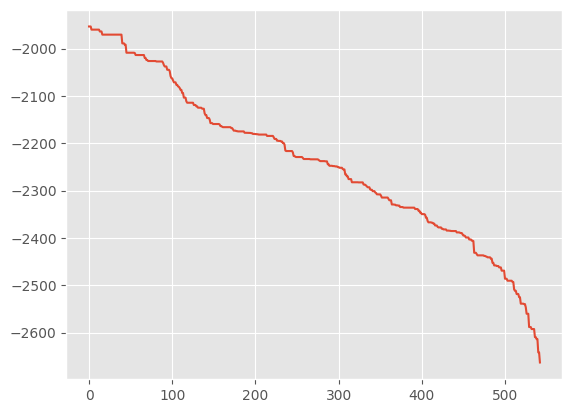

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]


target,Cloudy,Rain,Sprinkler,Wet_Grass
source,,,,
Cloudy,False,True,True,False
Rain,False,False,False,True
Sprinkler,False,False,False,True
Wet_Grass,False,False,False,False


In [5]:
# Learn the DAG in data using Bayesian structure learning and return all possible DAGs:
model = bn.structure_learning.fit(sprinkler_df, methodtype='exhaustivesearch', scoretype='bic', return_all_dags=True)

# Compute edge weights using ChiSquare independence test.
model = bn.independence_test(model, sprinkler_df, test='chi_square', prune=False)

# print adjacency matrix
display(model['adjmat'])

[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


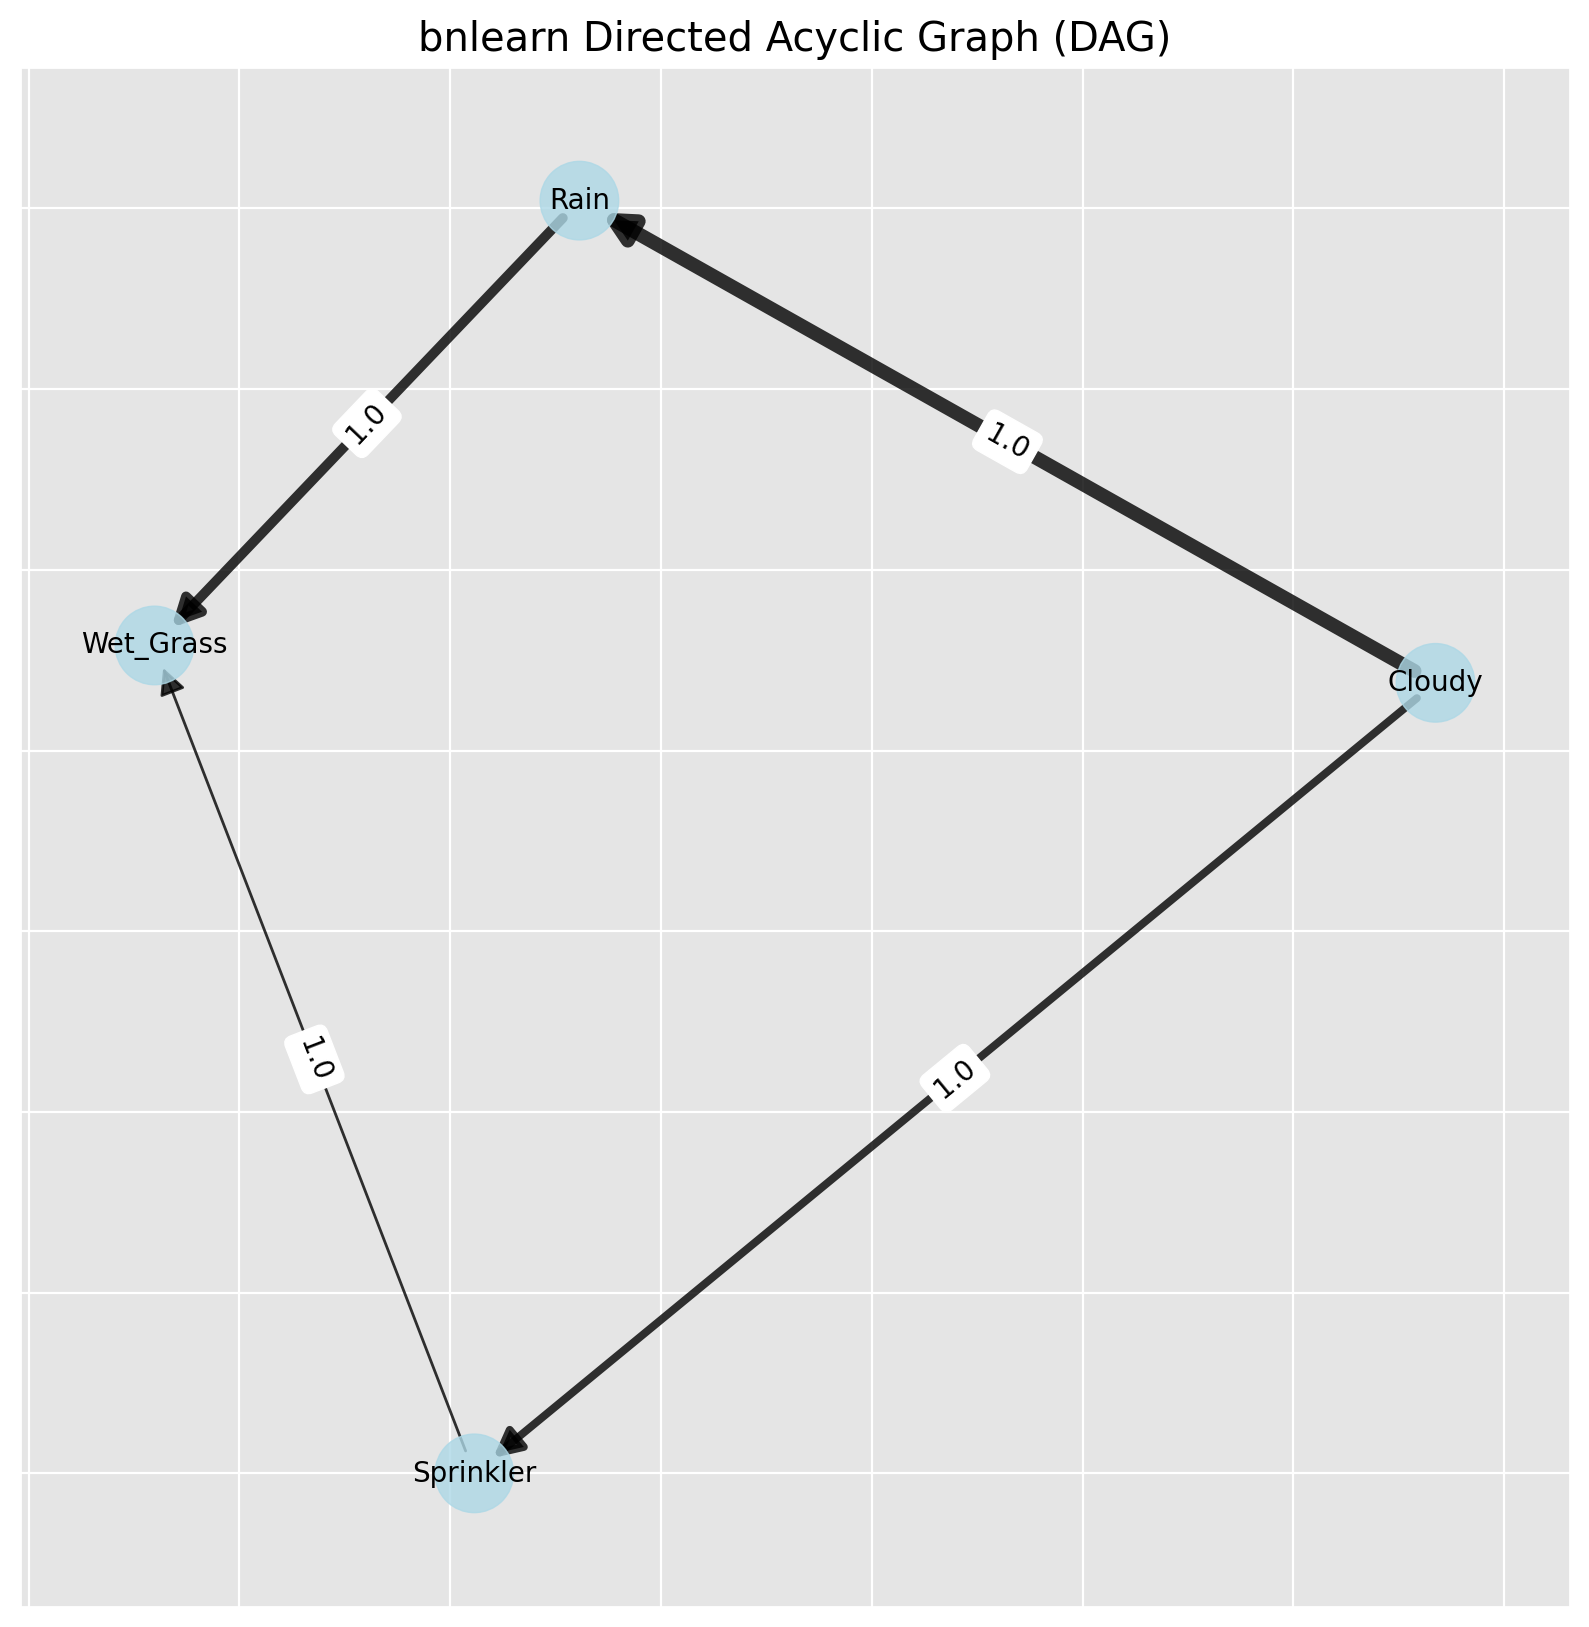

[08-02-2026 12:59:47] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 12:59:47] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 12:59:47] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 12:59:47] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


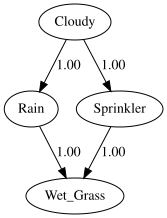

In [6]:
# Plot the best DAG
G = bn.plot(model, interactive=False)

# Plot using graphiviz
dot = bn.plot_graphviz(model)

# Store to pdf
dot.view(filename="bnlearn_sprinkler")

display(dot)

,LVFAILURE,HISTORY,LVEDVOLUME,CVP,PCWP,HYPOVOLEMIA,STROKEVOLUME,ERRLOWOUTPUT,HRBP,HR,ERRCAUTER,HREKG,HRSAT,ANAPHYLAXIS,TPR,ARTCO2,EXPCO2,VENTLUNG,INTUBATION,MINVOL,FIO2,PVSAT,VENTALV,SAO2,SHUNT,PULMEMBOLUS,PAP,PRESS,KINKEDTUBE,VENTTUBE,MINVOLSET,VENTMACH,DISCONNECT,CATECHOL,INSUFFANESTH,CO,BP
0,1,1,1,1,1,1,1,1,2,2,1,2,2,1,1,2,1,0,0,0,1,0,0,0,0,1,1,1,1,1,1,2,1,1,1,2,2
1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,2,2,1,0,0,0,1,0,0,0,0,1,1,2,1,1,1,2,1,1,1,1,1
2,1,1,0,0,1,1,1,1,2,2,1,2,2,1,1,2,1,0,0,0,1,0,0,0,0,1,1,3,1,1,1,2,1,1,1,2,1
3,1,1,1,1,1,1,1,1,2,2,1,2,2,1,1,2,1,0,0,0,1,0,0,0,0,1,1,2,1,1,1,2,1,1,0,2,0
4,1,1,1,1,1,1,2,1,2,2,1,2,2,1,0,2,1,0,0,0,1,0,0,0,0,1,2,1,1,1,1,2,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,1,1,1,1,2,2,1,2,2,1,0,2,1,0,0,0,1,0,0,0,0,1,1,3,1,1,1,2,1,1,1,2,0
9996,1,1,1,0,0,1,0,1,2,2,0,1,1,1,1,2,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,2,1,1,1,0,0
9997,1,1,1,1,1,1,1,1,2,2,1,2,2,1,0,0,1,1,0,0,1,2,3,2,0,1,1,3,1,0,1,0,1,1,0,2,0
9998,1,1,1,1,1,1,1,1,0,2,1,2,2,1,0,2,1,0,0,0,1,0,0,0,0,1,1,2,1,1,1,2,1,1,1,2,0


[bnlearn] >Computing best DAG using [hillclimbsearch]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


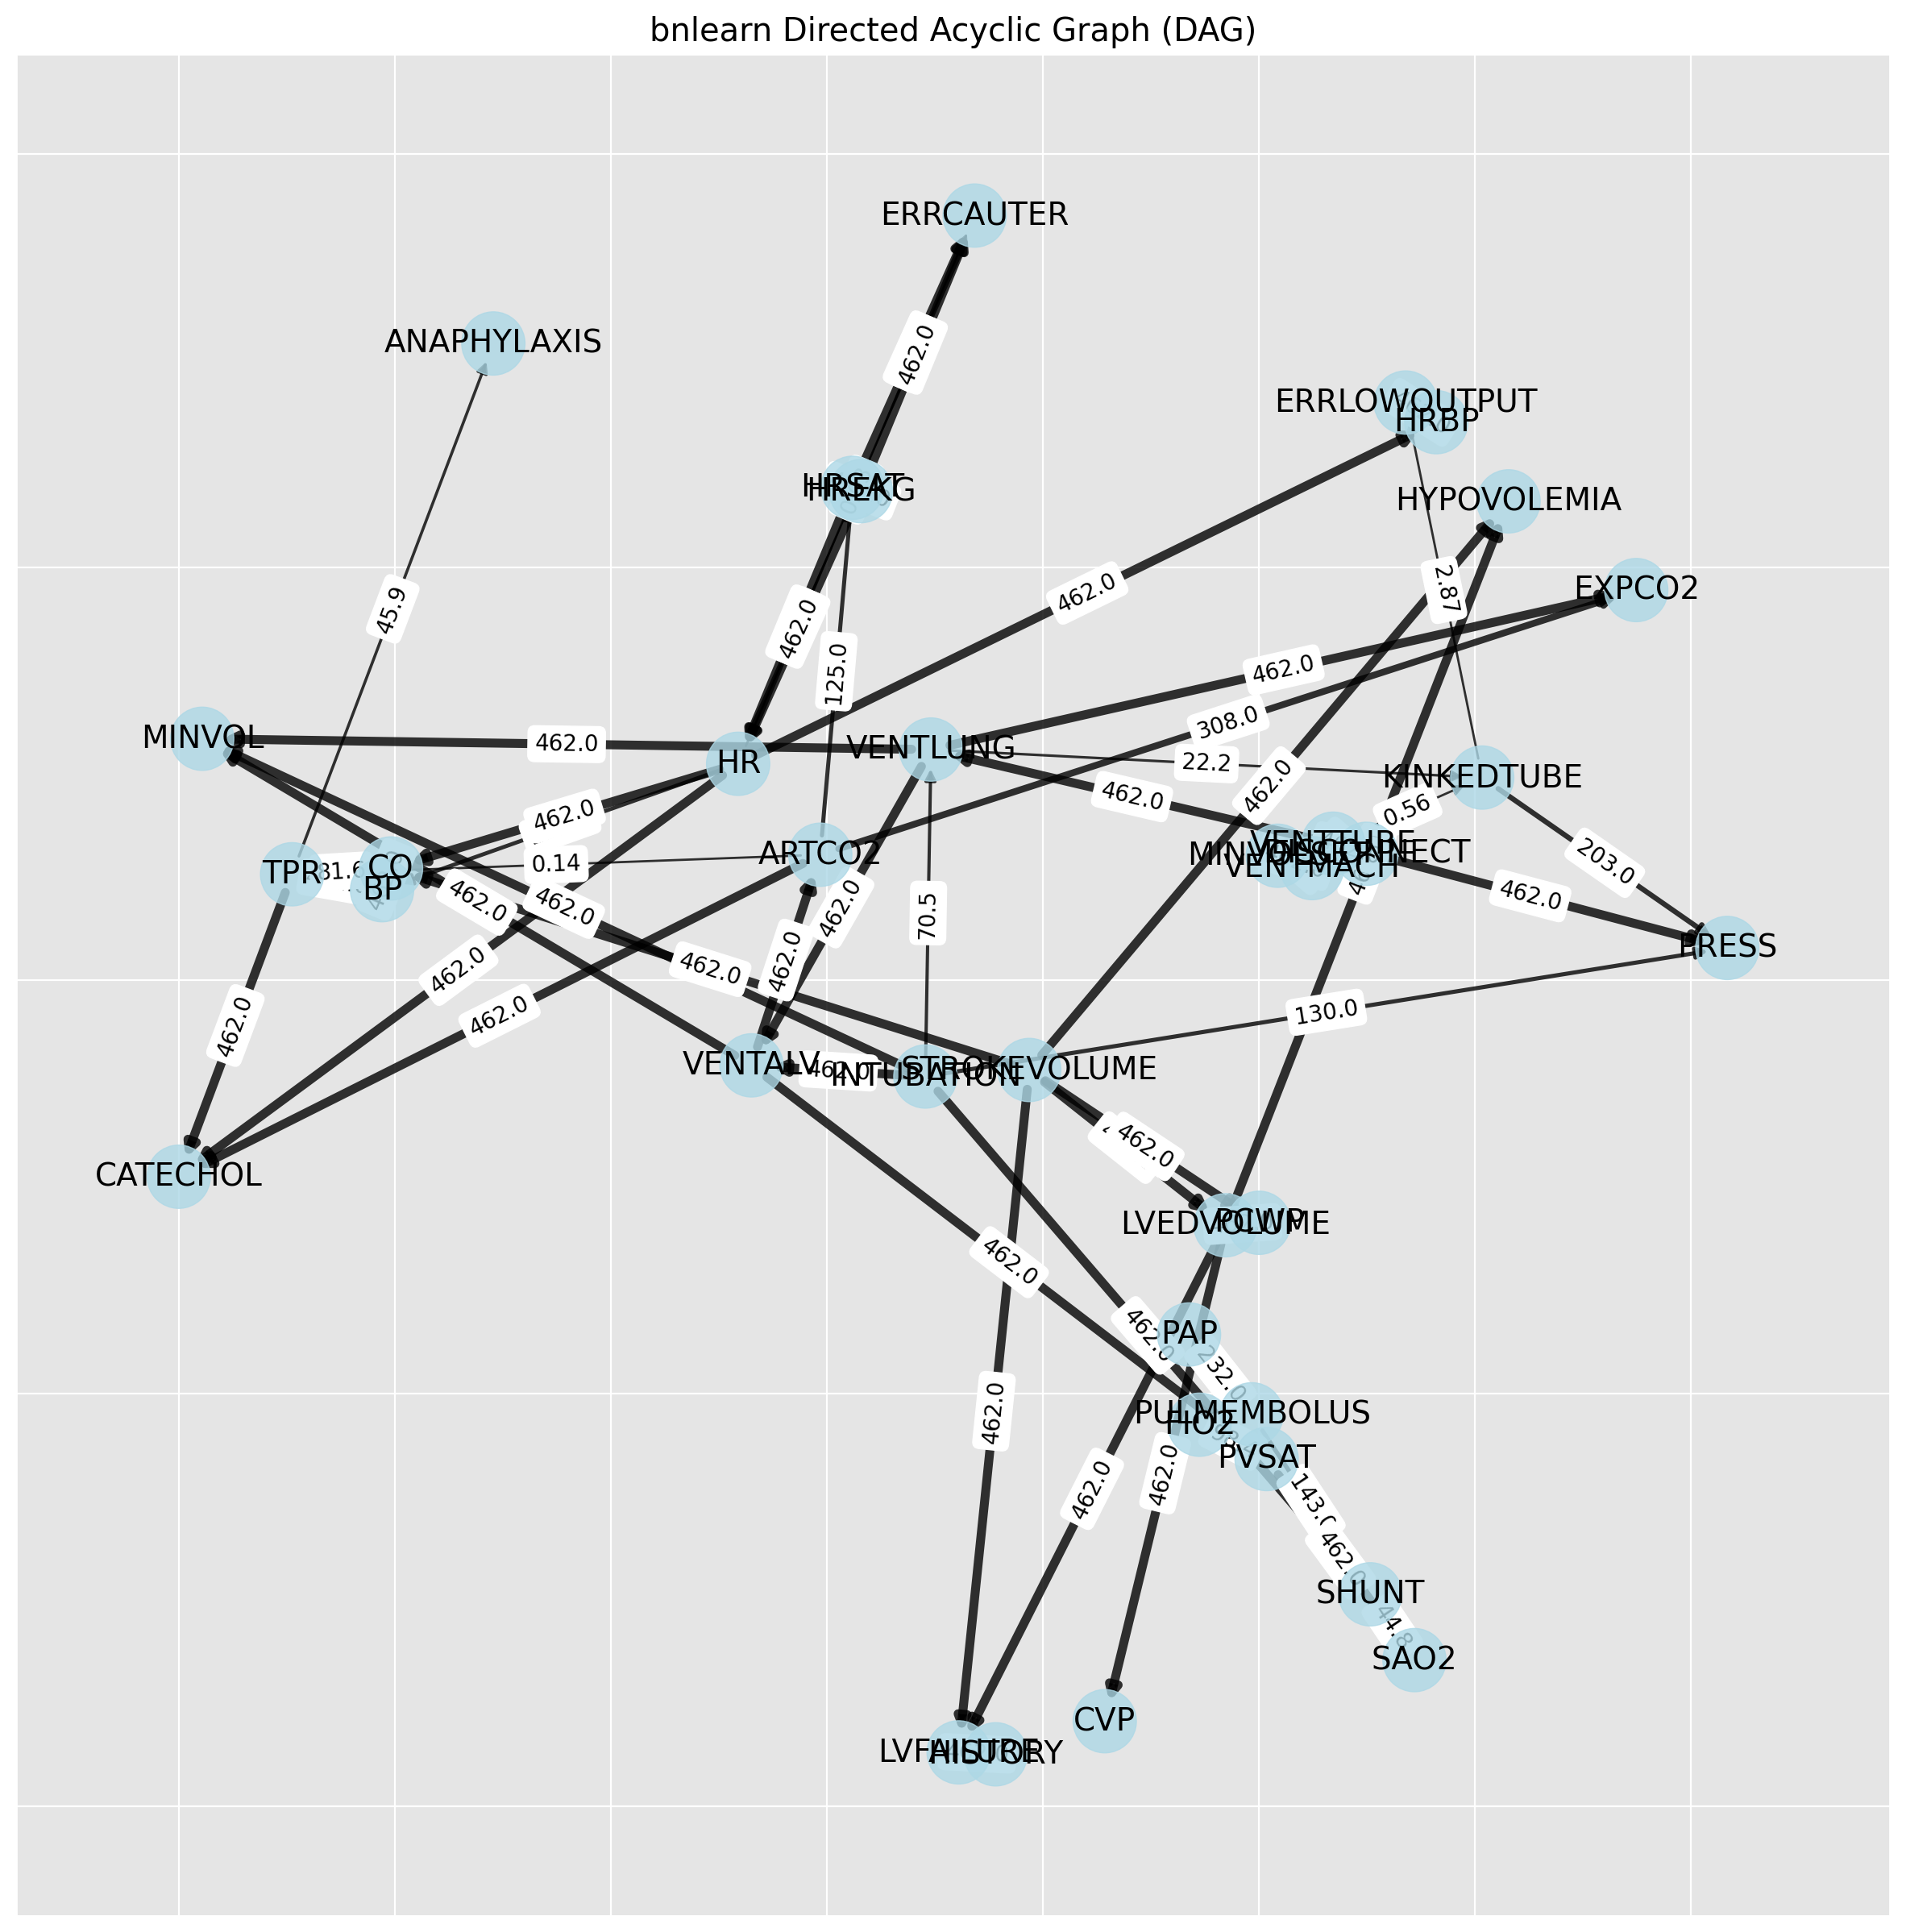

[08-02-2026 13:01:03] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:01:03] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:01:03] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 13:01:03] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


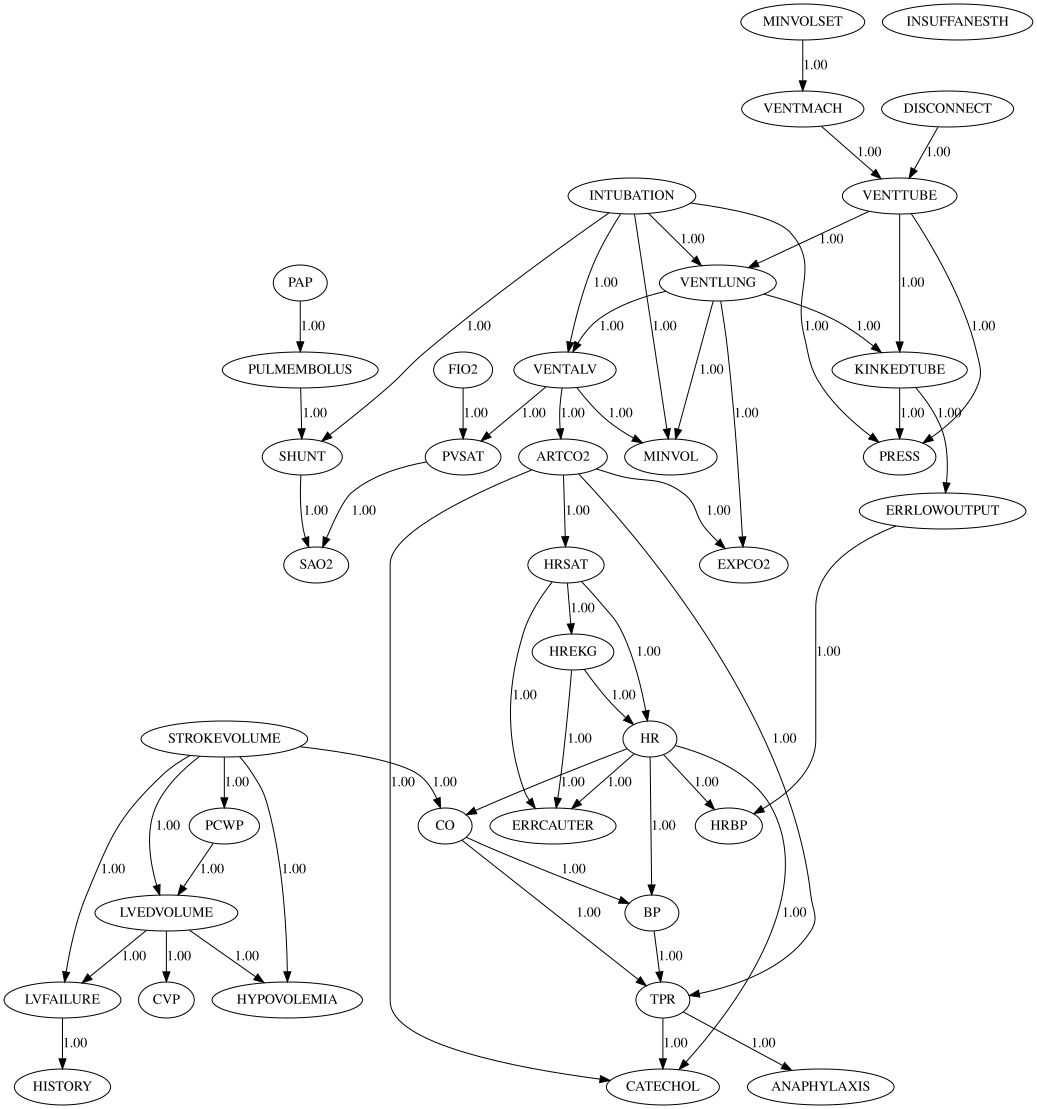

In [7]:
# Load Alarm dataset
alarm_df = bn.import_example('alarm')

display(alarm_df)

# Learn the DAG in data using hillclimbsearch and BIC
model = bn.structure_learning.fit(alarm_df, methodtype='hillclimbsearch', scoretype='bic')

# Compute edge weights using ChiSquare independence test.
model = bn.independence_test(model, alarm_df, test='chi_square', prune=False)

# Plot the best DAG
bn.plot(model, edge_labels='pvalue', params_static={'maxscale': 4, 'figsize': (15, 15), 'font_size': 14, 'arrowsize': 10})

# Plot using graphiviz
dot = bn.plot_graphviz(model)

# Store to pdf
dot.view(filename='bnlearn_alarm')

display(dot)

In [8]:
# Download dataset
auto_mpg_df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original',
                 delim_whitespace=True, header=None,
                 names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name'])

# Cleaning
df = auto_mpg_df.copy()
df.dropna(inplace=True)
df.drop(['model year', 'origin', 'car name'], axis=1, inplace=True)

# Show dataset
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration
0,18.00000000,8.00000000,307.00000000,130.00000000,3504.00000000,12.00000000
1,15.00000000,8.00000000,350.00000000,165.00000000,3693.00000000,11.50000000
2,18.00000000,8.00000000,318.00000000,150.00000000,3436.00000000,11.00000000
3,16.00000000,8.00000000,304.00000000,150.00000000,3433.00000000,12.00000000
4,17.00000000,8.00000000,302.00000000,140.00000000,3449.00000000,10.50000000


In [9]:
# Define horsepower bins based on domain knowledge
bins = [0, 100, 150, df['horsepower'].max()]
labels = ['low', 'medium', 'high']

# Discretize horsepower using the defined bins
df['horsepower_category'] = pd.cut(df['horsepower'], bins=bins, labels=labels, include_lowest=True)
display(df[['horsepower', 'horsepower_category']].head())

# Set the cylinder to integers
df['cylinders'] = df['cylinders'].astype(int)

,horsepower,horsepower_category
0,130.00000000,medium
1,165.00000000,high
2,150.00000000,medium
3,150.00000000,medium
4,140.00000000,medium


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


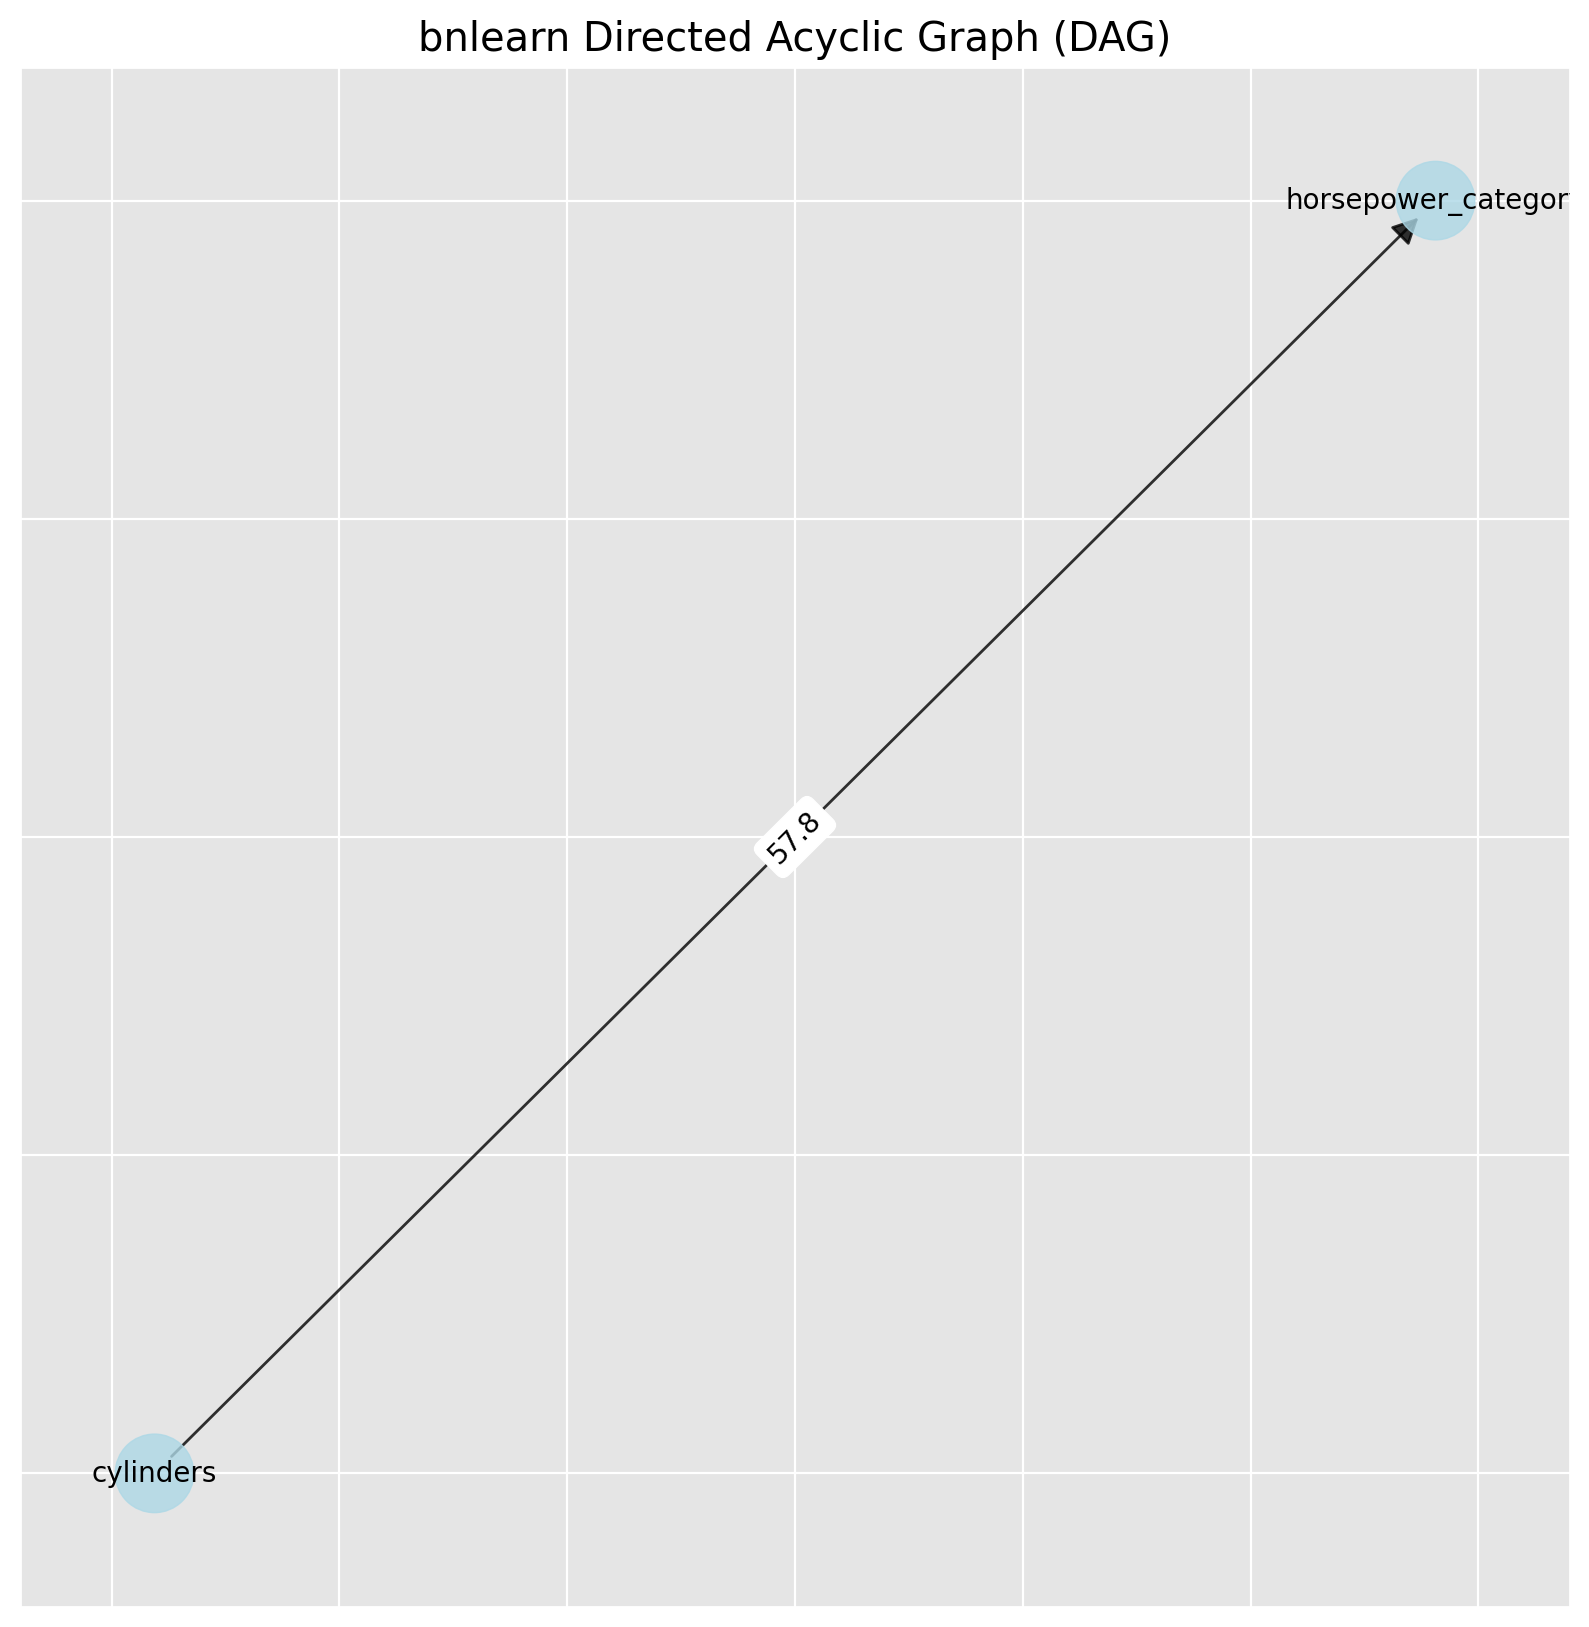

[08-02-2026 13:01:45] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:01:45] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:01:45] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 13:01:45] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


[bnlearn] >Setting edge labels to pvalue.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..


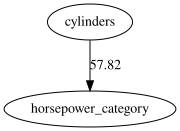

In [10]:
# Structure learning
model = bn.structure_learning.fit(df, methodtype='hc')

# Compute edge strength
model = bn.independence_test(model, df)

# Make plot and put the -log10(pvalues) on the edges
bn.plot(model, edge_labels='pvalue')
dotgraph = bn.plot_graphviz(model, edge_labels='pvalue')

dotgraph.view(filename="bnlearn_autompg")

display(dotgraph)

[08-02-2026 13:01:56] [distfit.distfit] [INFO] fit
[08-02-2026 13:01:56] [distfit.distfit] [INFO] transform
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [norm      ] [0.00 sec] [RSS: 0.00311047] [loc=15.541 scale=2.755]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [expon     ] [0.00 sec] [RSS: 0.078009] [loc=8.000 scale=7.541]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [pareto    ] [0.00 sec] [RSS: 0.078009] [loc=-536870904.000 scale=536870912.000]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [dweibull  ] [0.01 sec] [RSS: 0.00188367] [loc=15.259 scale=2.286]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [t         ] [0.15 sec] [RSS: 0.00273985] [loc=15.503 scale=2.661]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [genextreme] [0.08 sec] [RSS: 0.00313241] [loc=14.463 scale=2.641]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [gamma     ] [0.03 sec] [RSS: 0.00266128] [loc=-7.964 scale=0.322]
[08-02-2026 13:01:56] [distfit.distfit] [INFO] [lognorm   ] [0.00 sec] [RSS: 0.0026

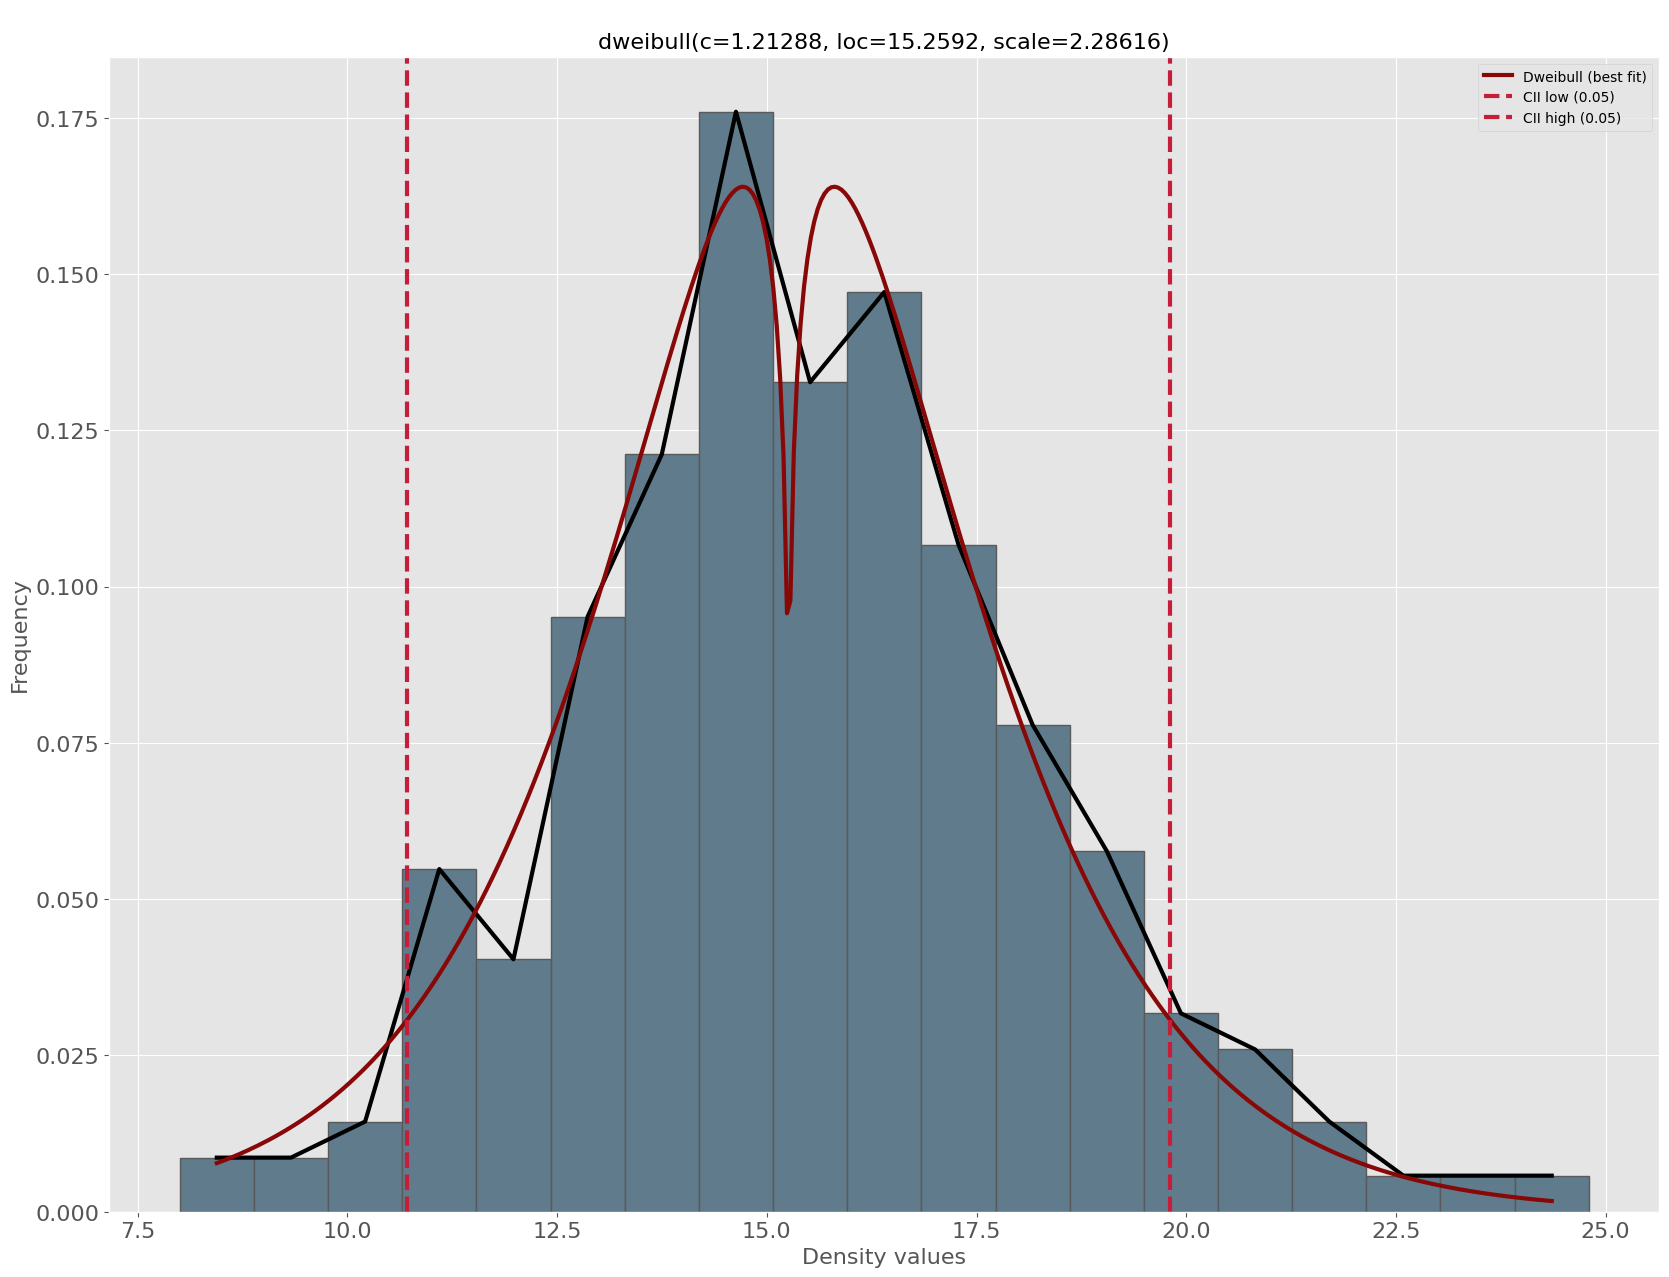

[08-02-2026 13:01:57] [distfit.distfit] [INFO] fit
[08-02-2026 13:01:57] [distfit.distfit] [INFO] transform
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [norm      ] [0.00 sec] [RSS: 0.00102439] [loc=23.446 scale=7.795]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [expon     ] [0.00 sec] [RSS: 0.003879] [loc=9.000 scale=14.446]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [pareto    ] [0.00 sec] [RSS: 0.003879] [loc=-4294967287.000 scale=4294967296.000]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [dweibull  ] [0.02 sec] [RSS: 0.00110162] [loc=23.362 scale=7.223]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [t         ] [0.17 sec] [RSS: 0.0010243] [loc=23.446 scale=7.795]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [genextreme] [0.10 sec] [RSS: 0.00079015] [loc=20.048 scale=6.710]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [gamma     ] [0.03 sec] [RSS: 0.000580449] [loc=7.077 scale=4.045]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [lognorm   ] [0.00 sec] [RSS: 0.00

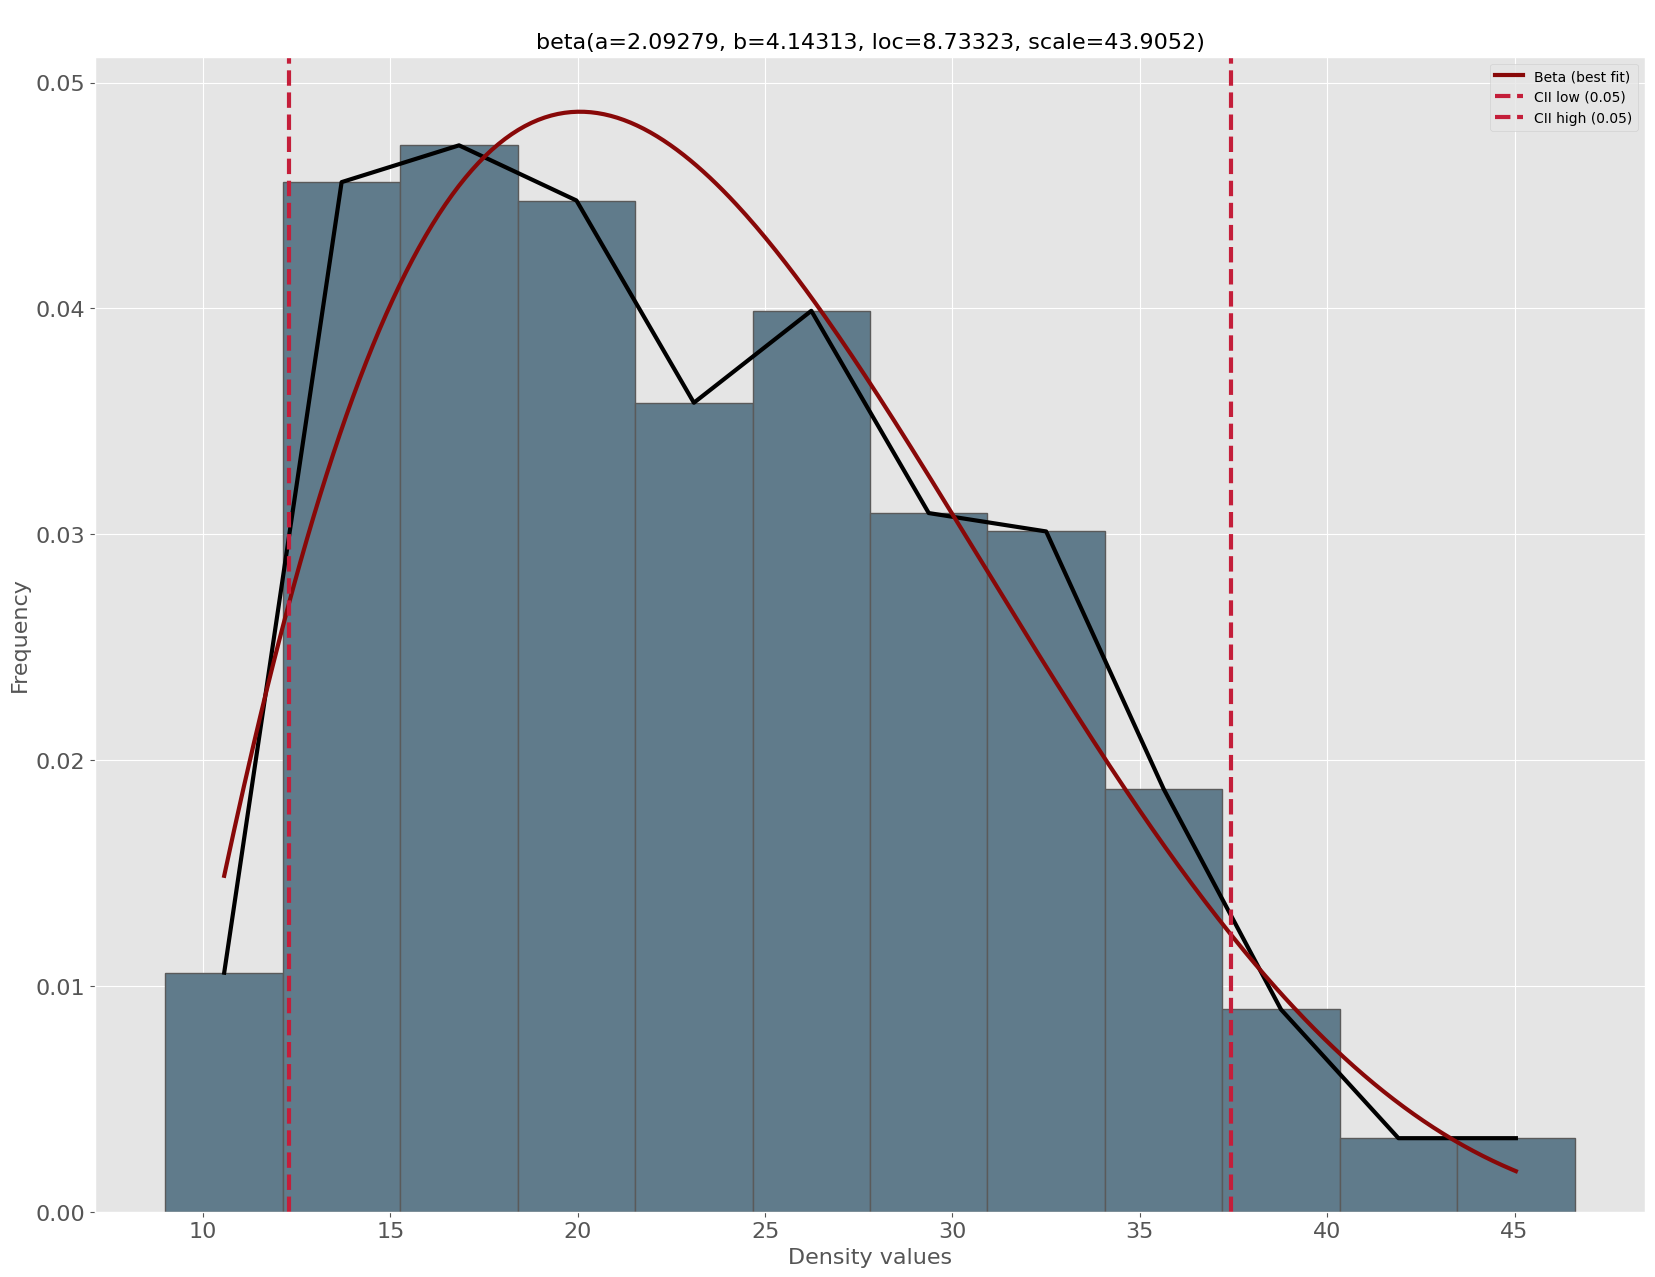

[08-02-2026 13:01:57] [distfit.distfit] [INFO] fit
[08-02-2026 13:01:57] [distfit.distfit] [INFO] transform
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [norm      ] [0.00 sec] [RSS: 4.88715e-05] [loc=194.412 scale=104.510]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [expon     ] [0.00 sec] [RSS: 1.65963e-05] [loc=68.000 scale=126.412]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [pareto    ] [0.00 sec] [RSS: 1.65963e-05] [loc=-17179869116.000 scale=17179869184.000]
[08-02-2026 13:01:57] [distfit.distfit] [INFO] [dweibull  ] [0.03 sec] [RSS: 3.04713e-05] [loc=191.470 scale=103.010]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [t         ] [0.15 sec] [RSS: 4.87313e-05] [loc=194.119 scale=104.664]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [genextreme] [0.23 sec] [RSS: 2.14049e-05] [loc=127.442 scale=56.062]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [gamma     ] [0.03 sec] [RSS: 1.92914e-05] [loc=67.862 scale=103.058]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [logn

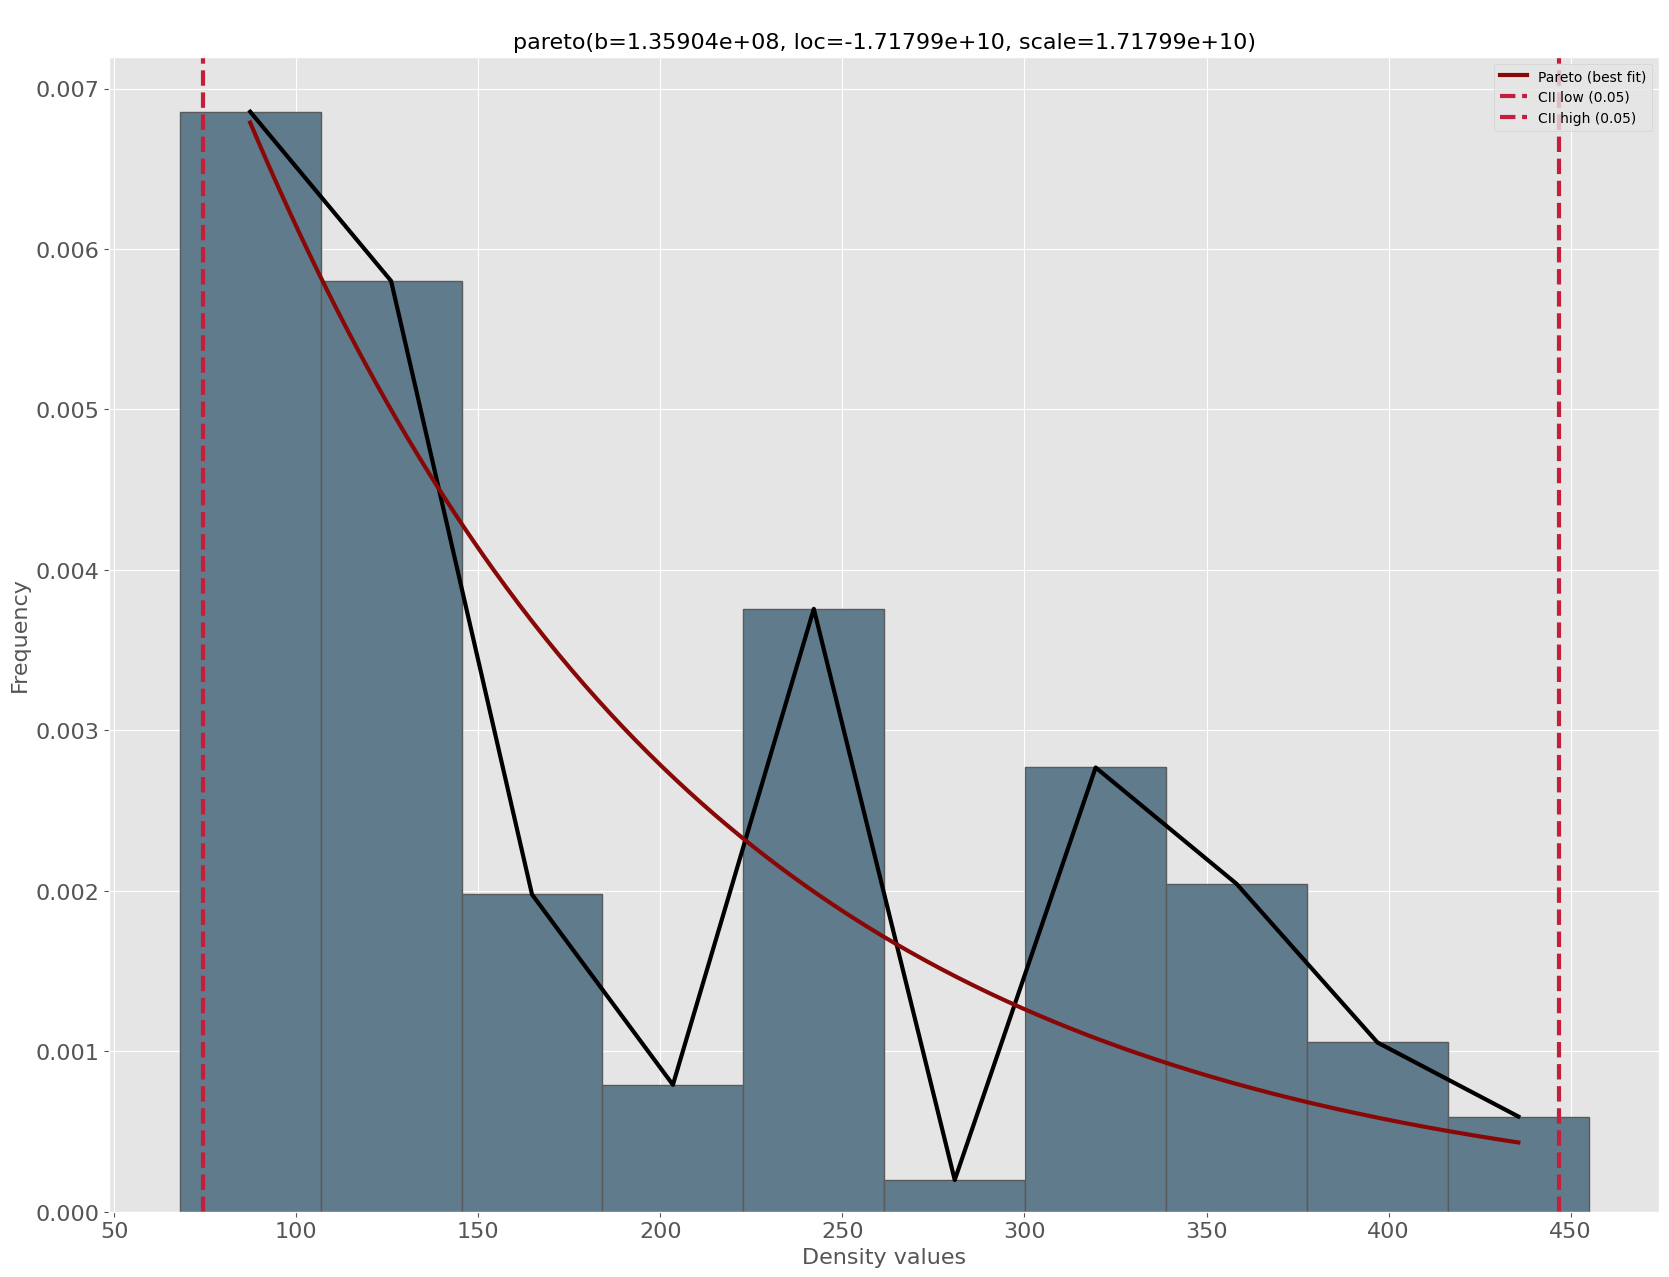

[08-02-2026 13:01:58] [distfit.distfit] [INFO] fit
[08-02-2026 13:01:58] [distfit.distfit] [INFO] transform
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [norm      ] [0.00 sec] [RSS: 1.94945e-07] [loc=2977.584 scale=848.318]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [expon     ] [0.00 sec] [RSS: 2.52817e-07] [loc=1613.000 scale=1364.584]
[08-02-2026 13:01:58] [distfit.distfit] [INFO] [pareto    ] [0.00 sec] [RSS: 2.52817e-07] [loc=-549755812275.000 scale=549755813888.000]
[08-02-2026 13:01:59] [distfit.distfit] [INFO] [dweibull  ] [0.02 sec] [RSS: 1.65373e-07] [loc=3050.406 scale=815.245]
[08-02-2026 13:01:59] [distfit.distfit] [INFO] [t         ] [0.12 sec] [RSS: 1.94945e-07] [loc=2977.584 scale=848.318]
[08-02-2026 13:01:59] [distfit.distfit] [INFO] [genextreme] [0.17 sec] [RSS: 1.15807e-07] [loc=2562.426 scale=662.128]
[08-02-2026 13:01:59] [distfit.distfit] [INFO] [gamma     ] [0.03 sec] [RSS: 7.37621e-08] [loc=1571.567 scale=582.662]
[08-02-2026 13:01:59] [distfit.distfit] 

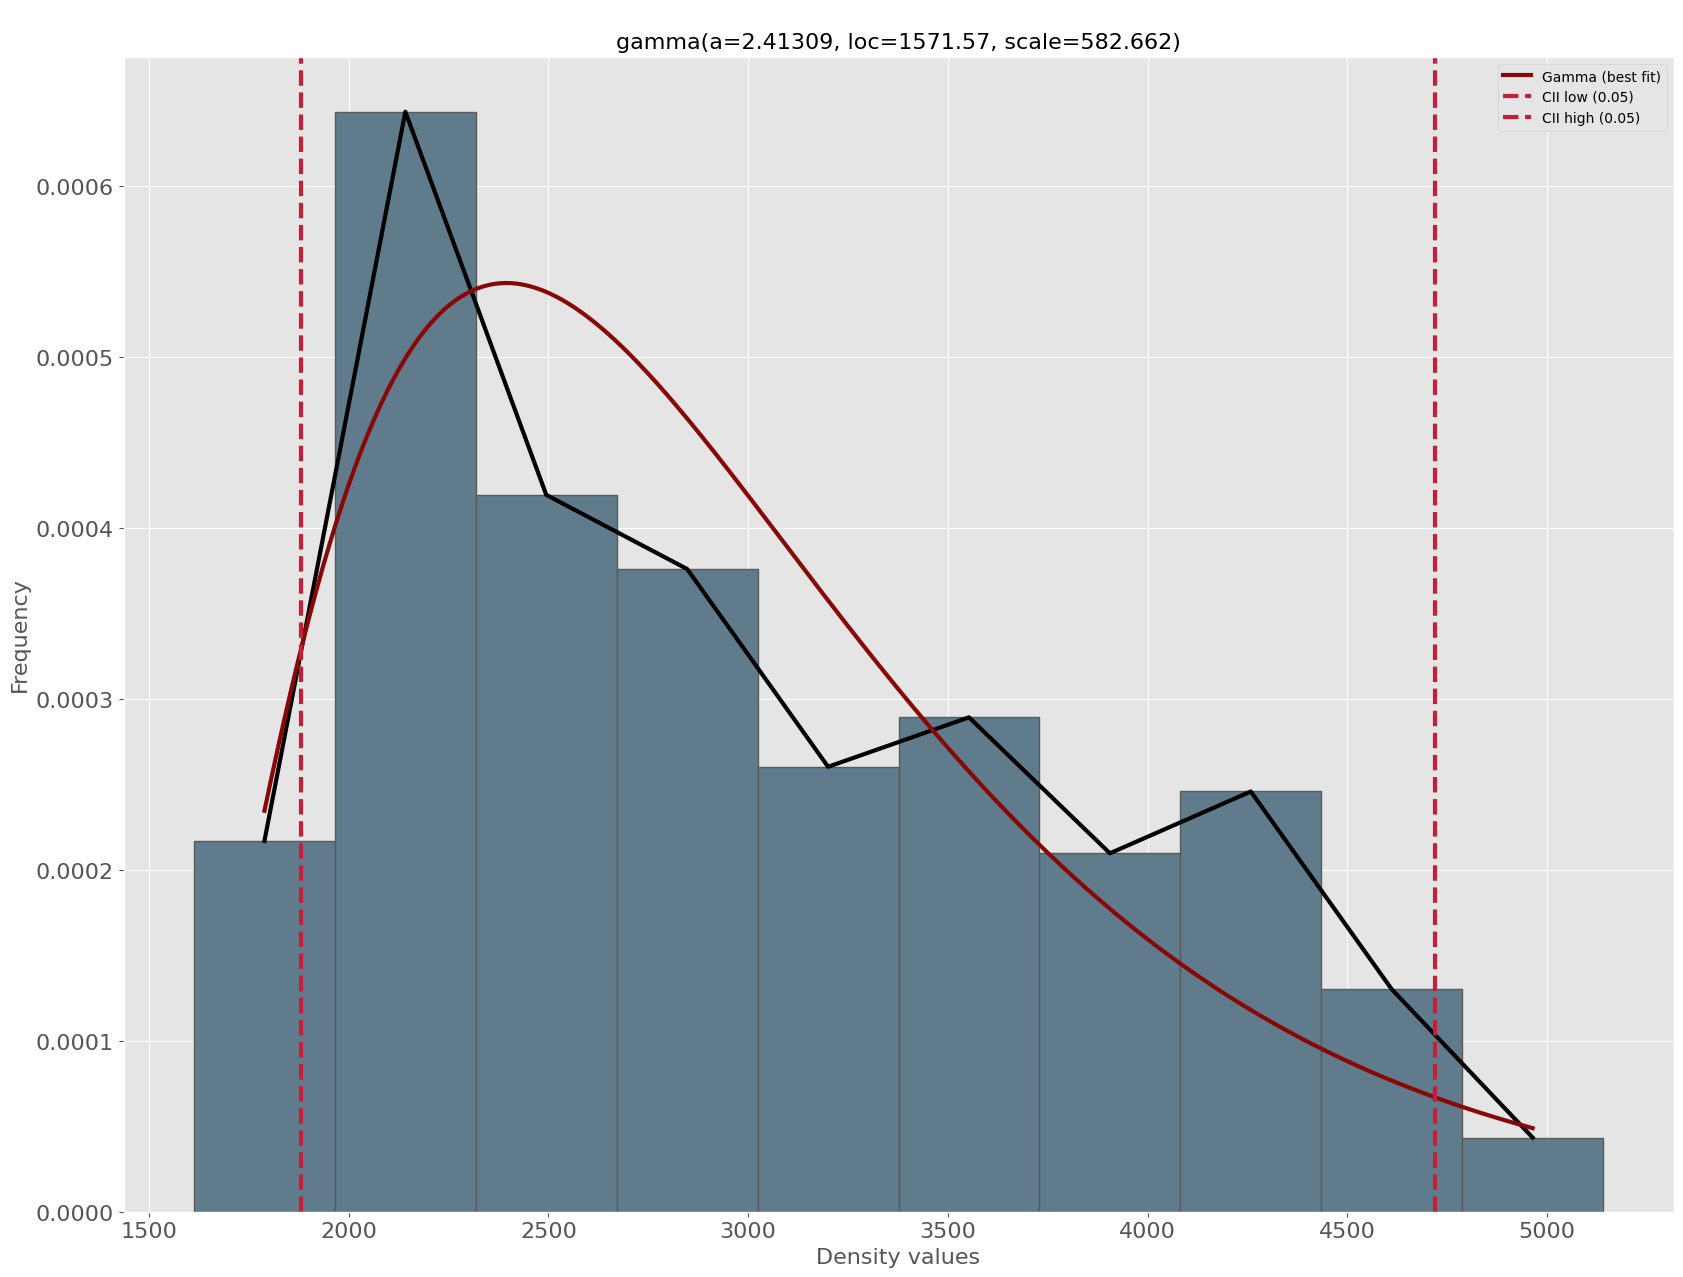

In [11]:
# Initialize and set 95% CII
dist = distfit(alpha=0.05)

# Fit Transform
dist.fit_transform(df['acceleration'])

# Make plot
dist.plot()
plt.show()
bins = [df['acceleration'].min(), dist.model['CII_min_alpha'], dist.model['CII_max_alpha'], df['acceleration'].max()]

# Discretize acceleration using the defined bins
df['acceleration_category'] = pd.cut(df['acceleration'], bins=bins, labels=['fast', 'normal', 'slow'], include_lowest=True)
del df['acceleration']

# For all remaining columns, the same approach can be performed:
cols = ['mpg', 'displacement', 'weight']

# Do for every variable
for col in cols:
    # Initialize and set 95% CII
    dist = distfit(alpha=0.05)
    dist.fit_transform(df[col])
    # Make plot
    dist.plot()
    plt.show()
    bins = [df[col].min(), dist.model['CII_min_alpha'], dist.model['CII_max_alpha'], df[col].max()]
    # Discretize acceleration using the defined bins
    df[col + '_category'] = pd.cut(df[col], bins=bins, labels=['low', 'medium', 'high'], include_lowest=True)
    del df[col]

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


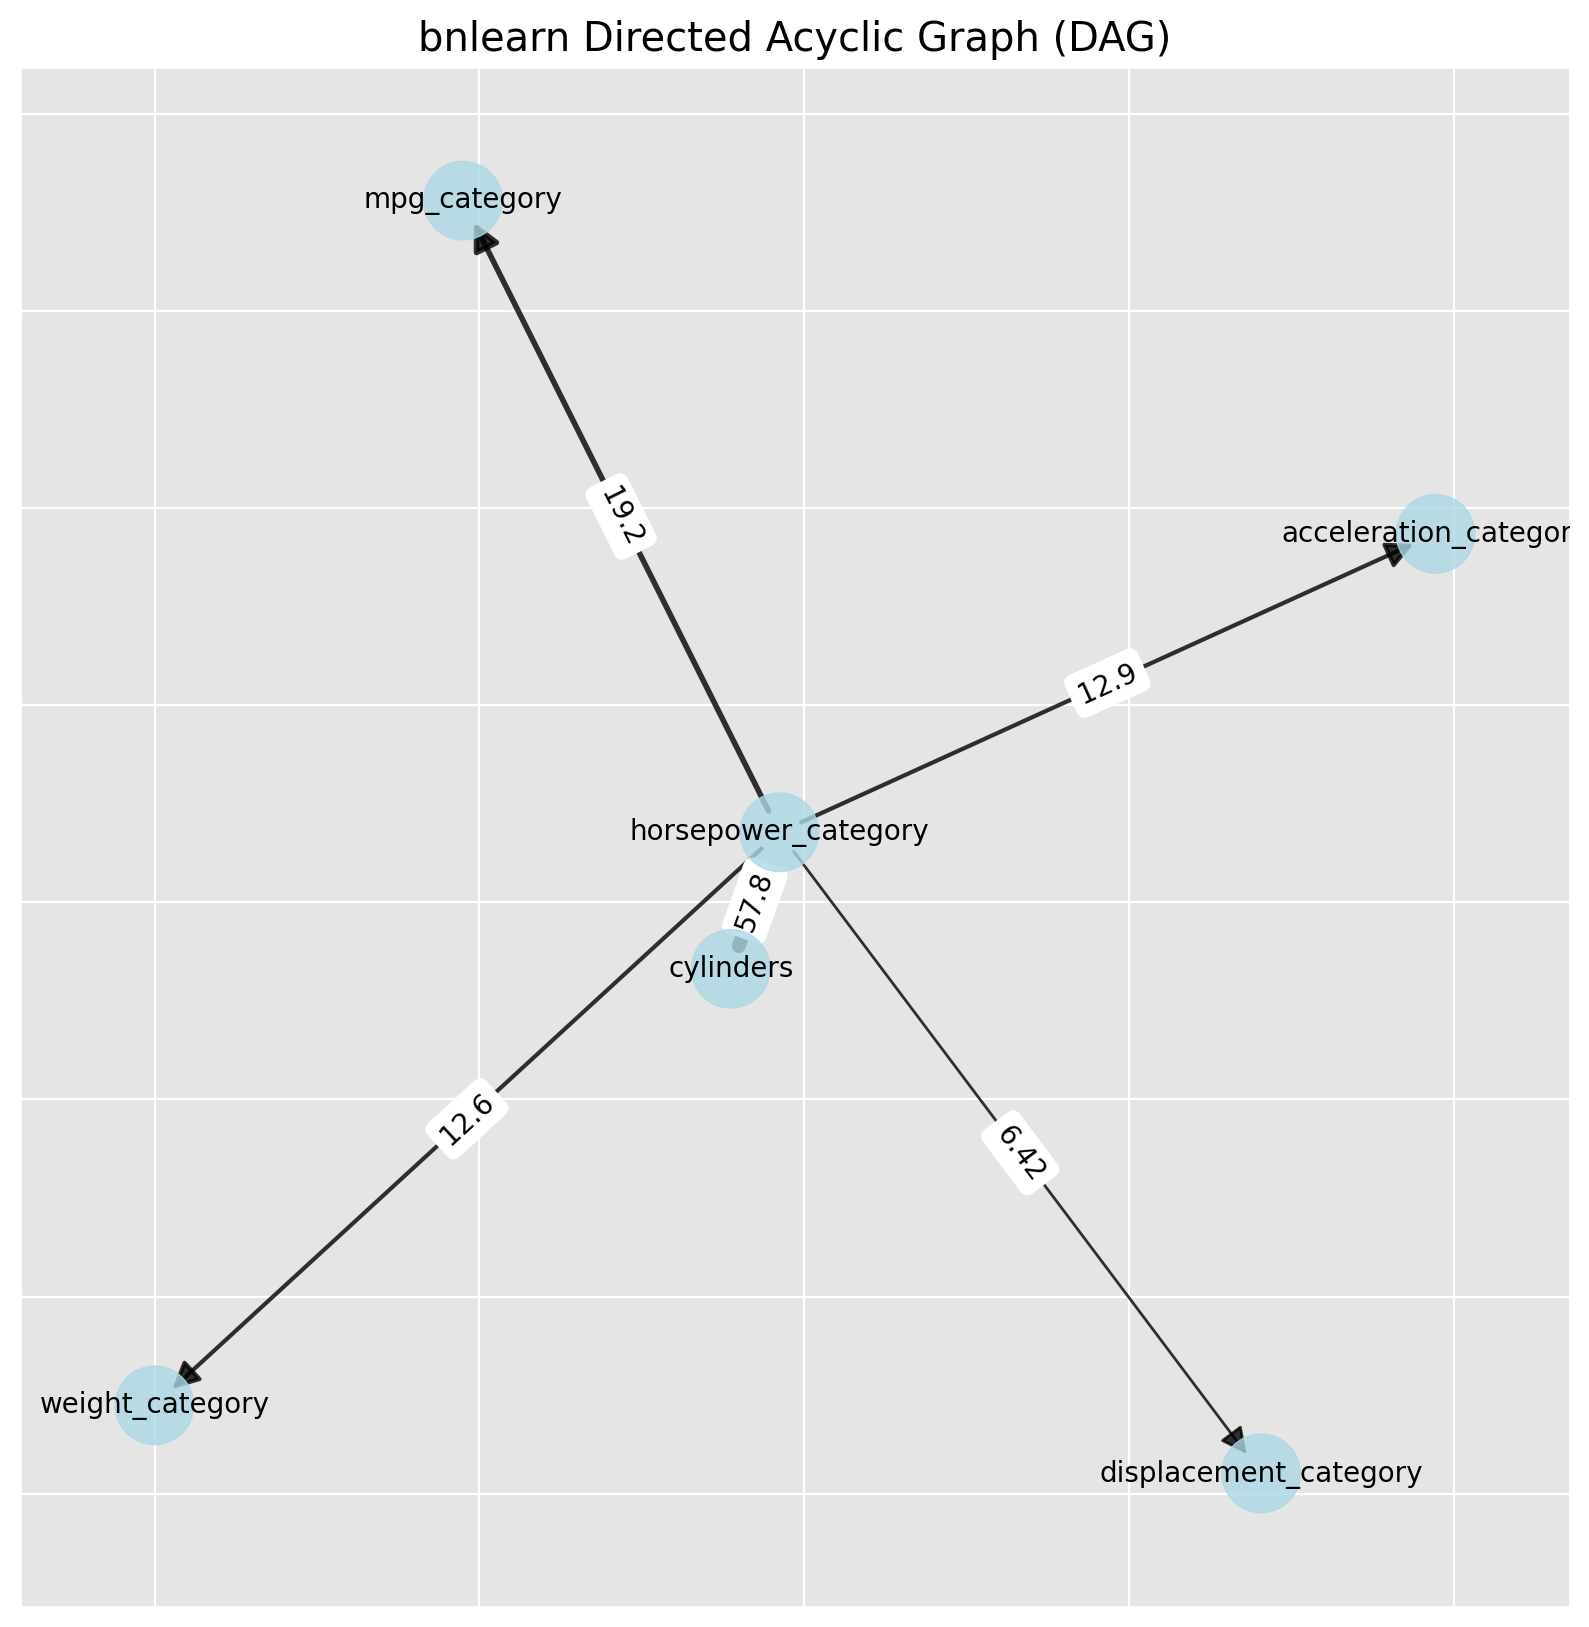

[08-02-2026 13:02:16] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:02:16] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:02:16] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 13:02:16] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


[bnlearn] >Setting edge labels to pvalue.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..


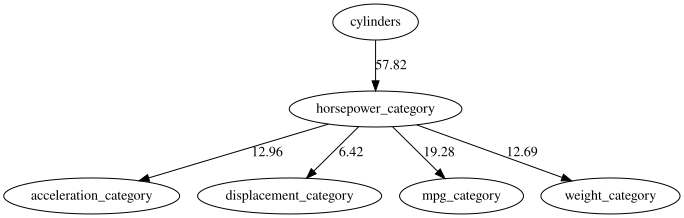

In [12]:
# Structure learning
model = bn.structure_learning.fit(df, methodtype='hc')

# Compute edge strength
model = bn.independence_test(model, df)

# Make plot and put the -log10(pvalues) on the edges
bn.plot(model, edge_labels='pvalue')
dotgraph = bn.plot_graphviz(model, edge_labels='pvalue')
display(dotgraph)

,x0,x1,x2,x3,x4,x5
0,2.36924606,16.18238616,4.13272778,0.62261627,14.85263944,9.57198503
1,2.68803370,16.52466169,3.97250808,0.61607207,18.17137262,11.15110373
2,3.55104868,23.90167341,6.28636100,0.98584744,22.92178879,14.21720193
3,3.27543667,21.26070727,5.71602385,0.81297829,20.88443275,13.57447302
4,2.21942558,14.08659599,3.26491071,0.44476131,15.14305125,9.73508553


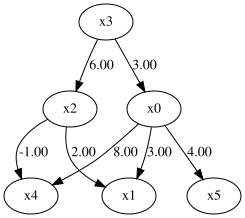

In [13]:
# Number of samples
n = 1000

# step 1
x3 = np.random.uniform(size=n)

# step 2
x0 = 3.0 * x3 + np.random.uniform(size=n)
x2 = 6.0 * x3 + np.random.uniform(size=n)

# step 3
x5 = 4.0 * x0 + np.random.uniform(size=n)

# step 4
x1 = 3.0 * x0 + 2.0 * x2 + np.random.uniform(size=n)
x4 = 8.0 * x0 - 1.0 * x2 + np.random.uniform(size=n)

df = pd.DataFrame(
    np.array([x0, x1, x2, x3, x4, x5]).T,
    columns=['x0', 'x1', 'x2', 'x3', 'x4', 'x5']
)

display(df.head())

# Adjacency / coefficient matrix
m = np.array([
    [0.0, 0.0, 0.0, 3.0, 0.0, 0.0],
    [3.0, 0.0, 2.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 6.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [8.0, 0.0, -1.0, 0.0, 0.0, 0.0],
    [4.0, 0.0, 0.0, 0.0, 0.0, 0.0],
])

dot = make_dot(m)
dot

[bnlearn] >Computing best DAG using [direct-lingam]


target,x0,x1,x2,x3,x4,x5
source,,,,,,
x0,0.00000000,3.02401317,0.00000000,0.00000000,8.05926087,4.00168413
x1,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
x2,0.00000000,1.99080992,0.00000000,0.00000000,-1.02488874,0.00000000
x3,2.96569870,0.00000000,5.97874417,0.00000000,0.00000000,0.00000000
x4,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
x5,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


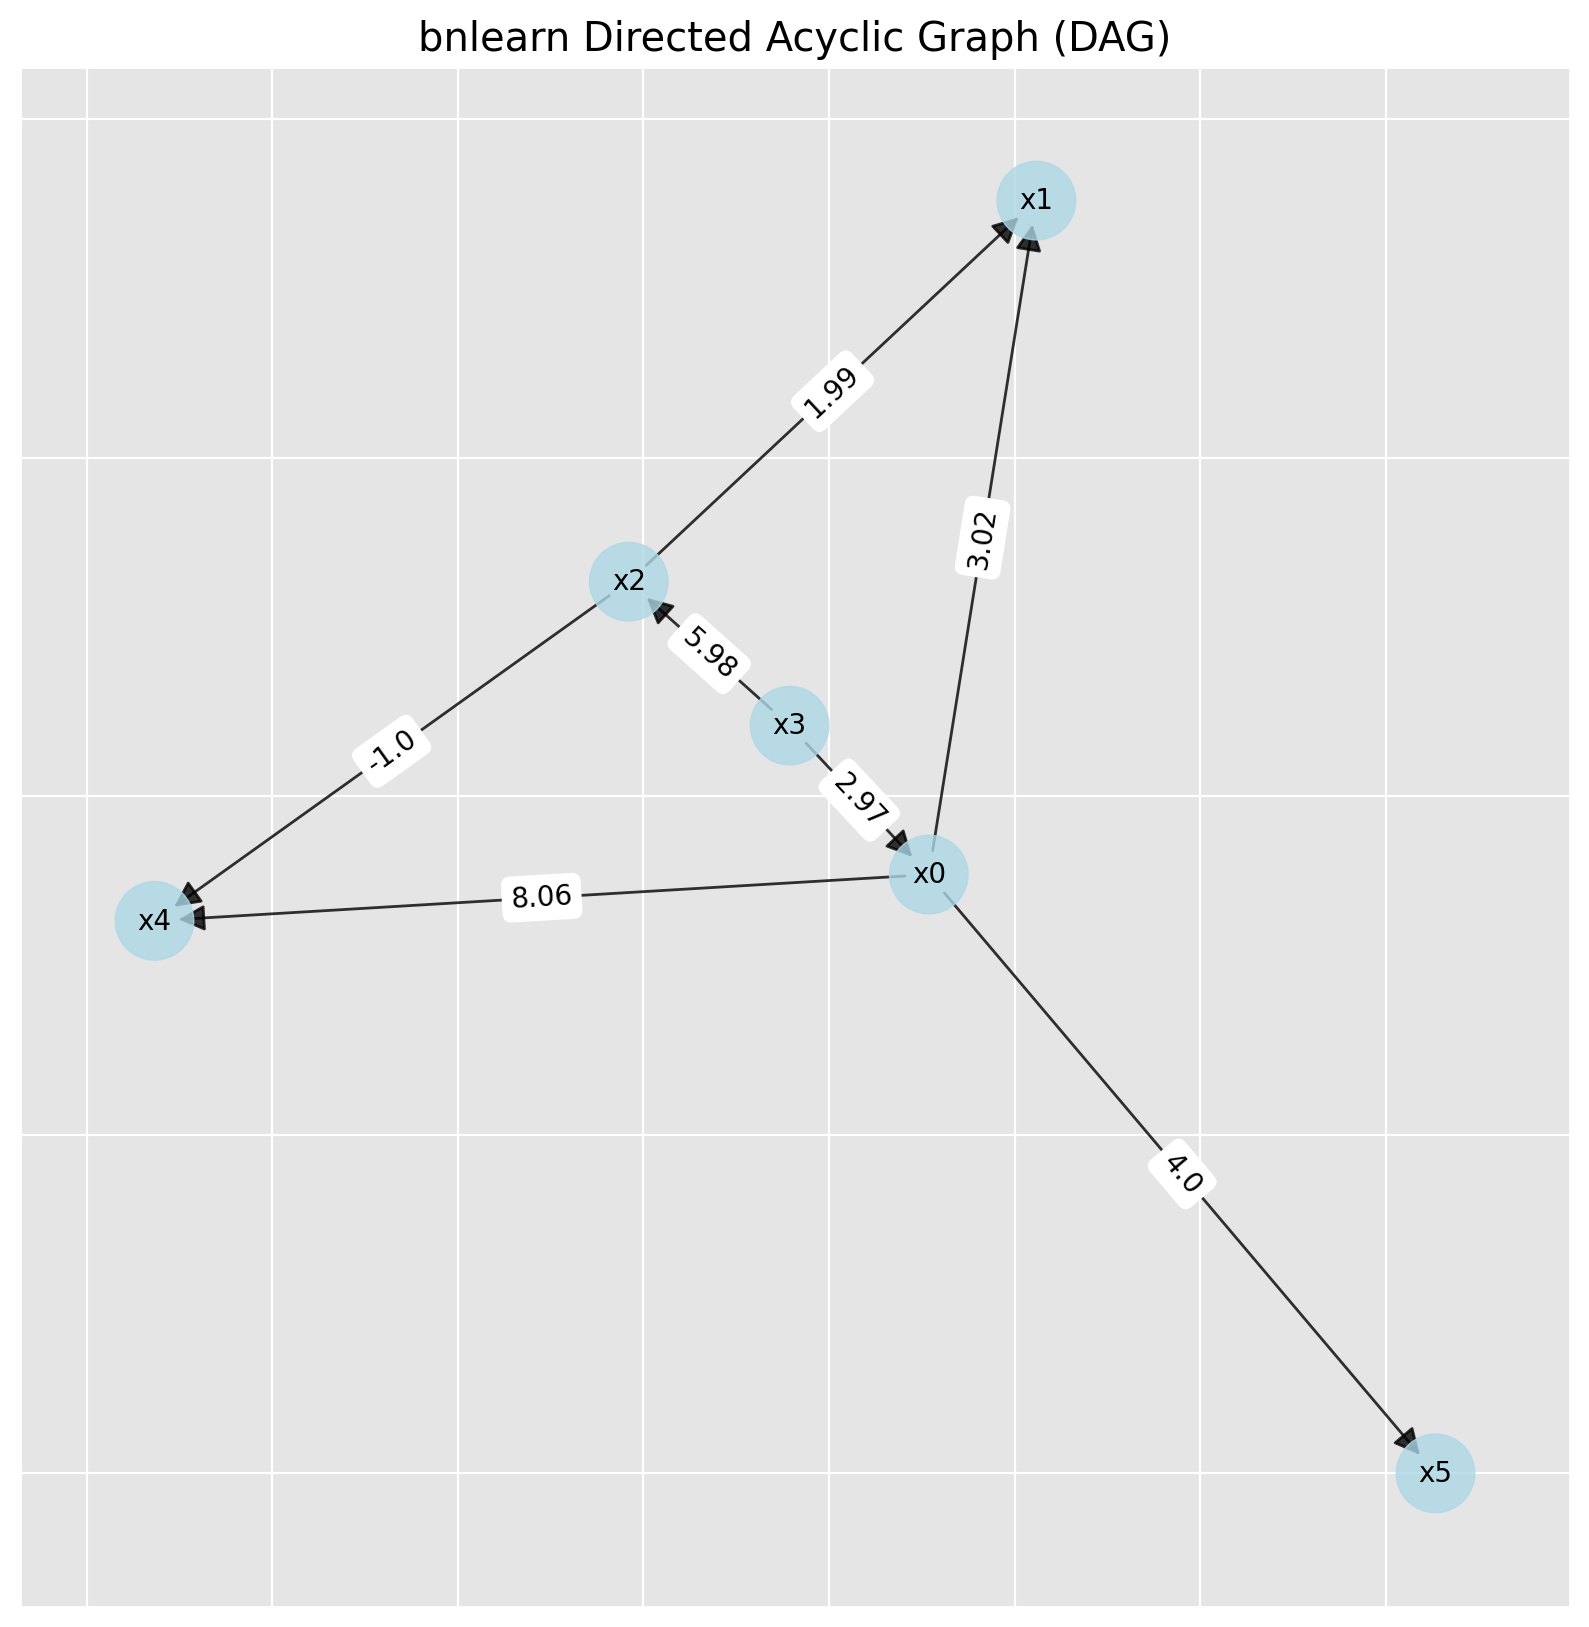

[bnlearn] >Compute edge strength with direct-lingam


target,x0,x1,x2,x3,x4,x5
source,,,,,,
x0,0.00000000,3.02401317,0.00000000,0.00000000,8.05926087,4.00168413
x1,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
x2,0.00000000,1.99080992,0.00000000,0.00000000,-1.02488874,0.00000000
x3,2.96569870,0.00000000,5.97874417,0.00000000,0.00000000,0.00000000
x4,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
x5,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


['x3', 'x2', 'x0', 'x1', 'x5', 'x4']

[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [dof] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


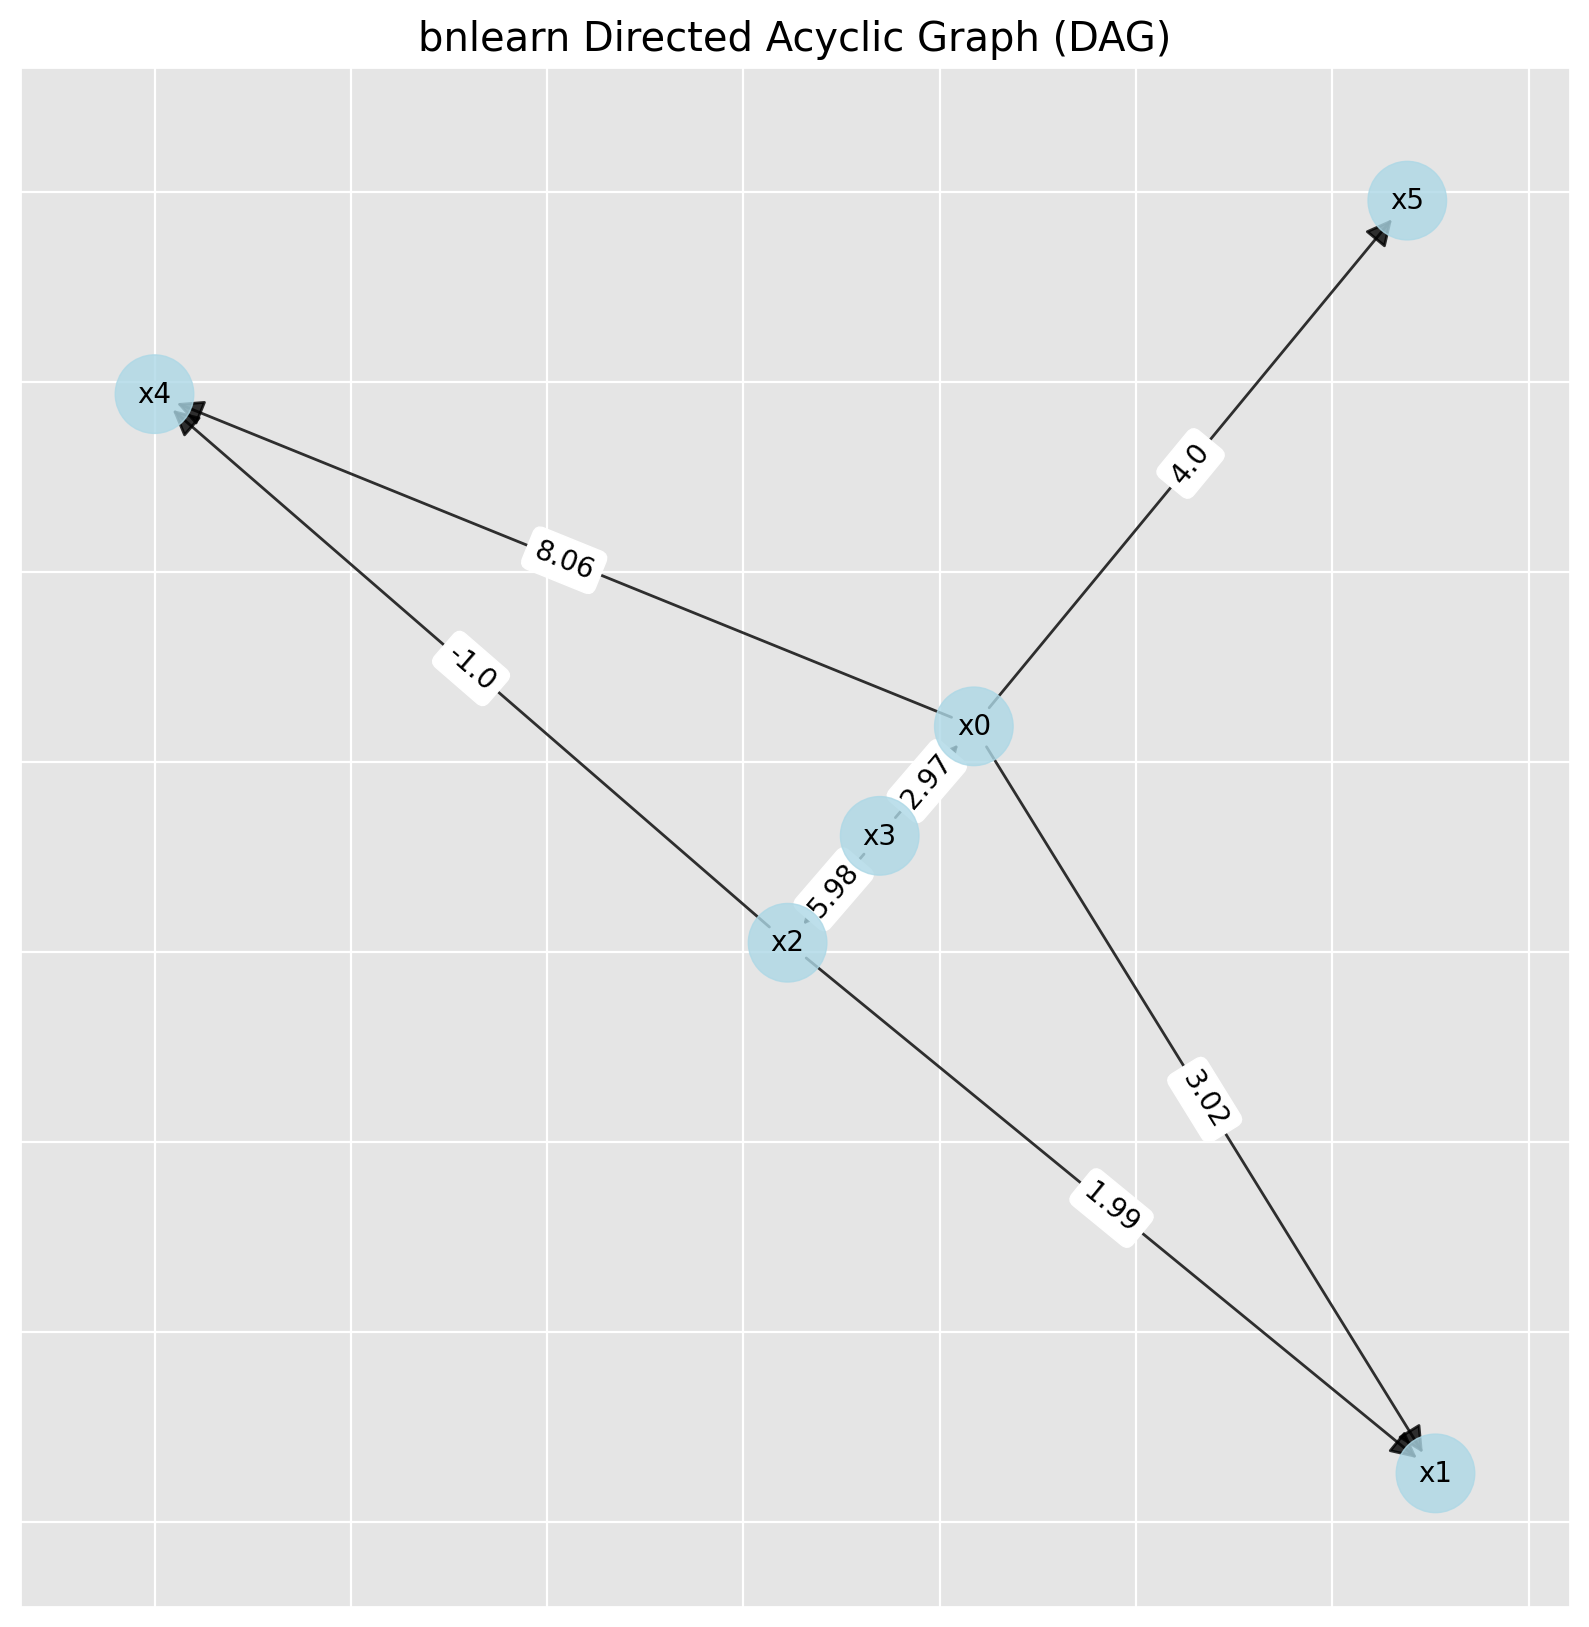

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'x0': array([0.04343614, 0.04714793]),
  'x1': array([ 0.63133731, -0.93572027]),
  'x4': array([-1.       ,  0.4842356]),
  'x5': array([0.59542613, 0.73883807]),
  'x2': array([-0.19375653, -0.23757607]),
  'x3': array([-0.07644304, -0.09692526])},
 'G': <networkx.classes.digraph.DiGraph at 0x7cbddf9d7e30>,
 'node_properties': {'x0': {'node_color': '#ADD8E6', 'node_size': 800},
  'x1': {'node_color': '#ADD8E6', 'node_size': 800},
  'x2': {'node_color': '#ADD8E6', 'node_size': 800},
  'x3': {'node_color': '#ADD8E6', 'node_size': 800},
  'x4': {'node_color': '#ADD8E6', 'node_size': 800},
  'x5': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('x0', 'x1'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': np.float64(0.08878434497464166),
   'value': np.float64(3.024013174474168)},
  ('x0', 'x4'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue

In [14]:
# Structure learning
model = bn.structure_learning.fit(df, methodtype='direct-lingam')

# When we no look at the output, we can see that the dependency values are very well recovered for the various variables.
display(model['adjmat'])

bn.plot(model)

# Compute edge strength with the chi_square test statistic
model = bn.independence_test(model, df, prune=False)
display(model['adjmat'])

# Using the causal_order_ properties, we can see the causal ordering as a result of the causal discovery.
display(model['causal_order'])

# We can draw a causal graph by utility funciton.
bn.plot(model)

[bnlearn] >Computing best DAG using [direct-lingam]
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


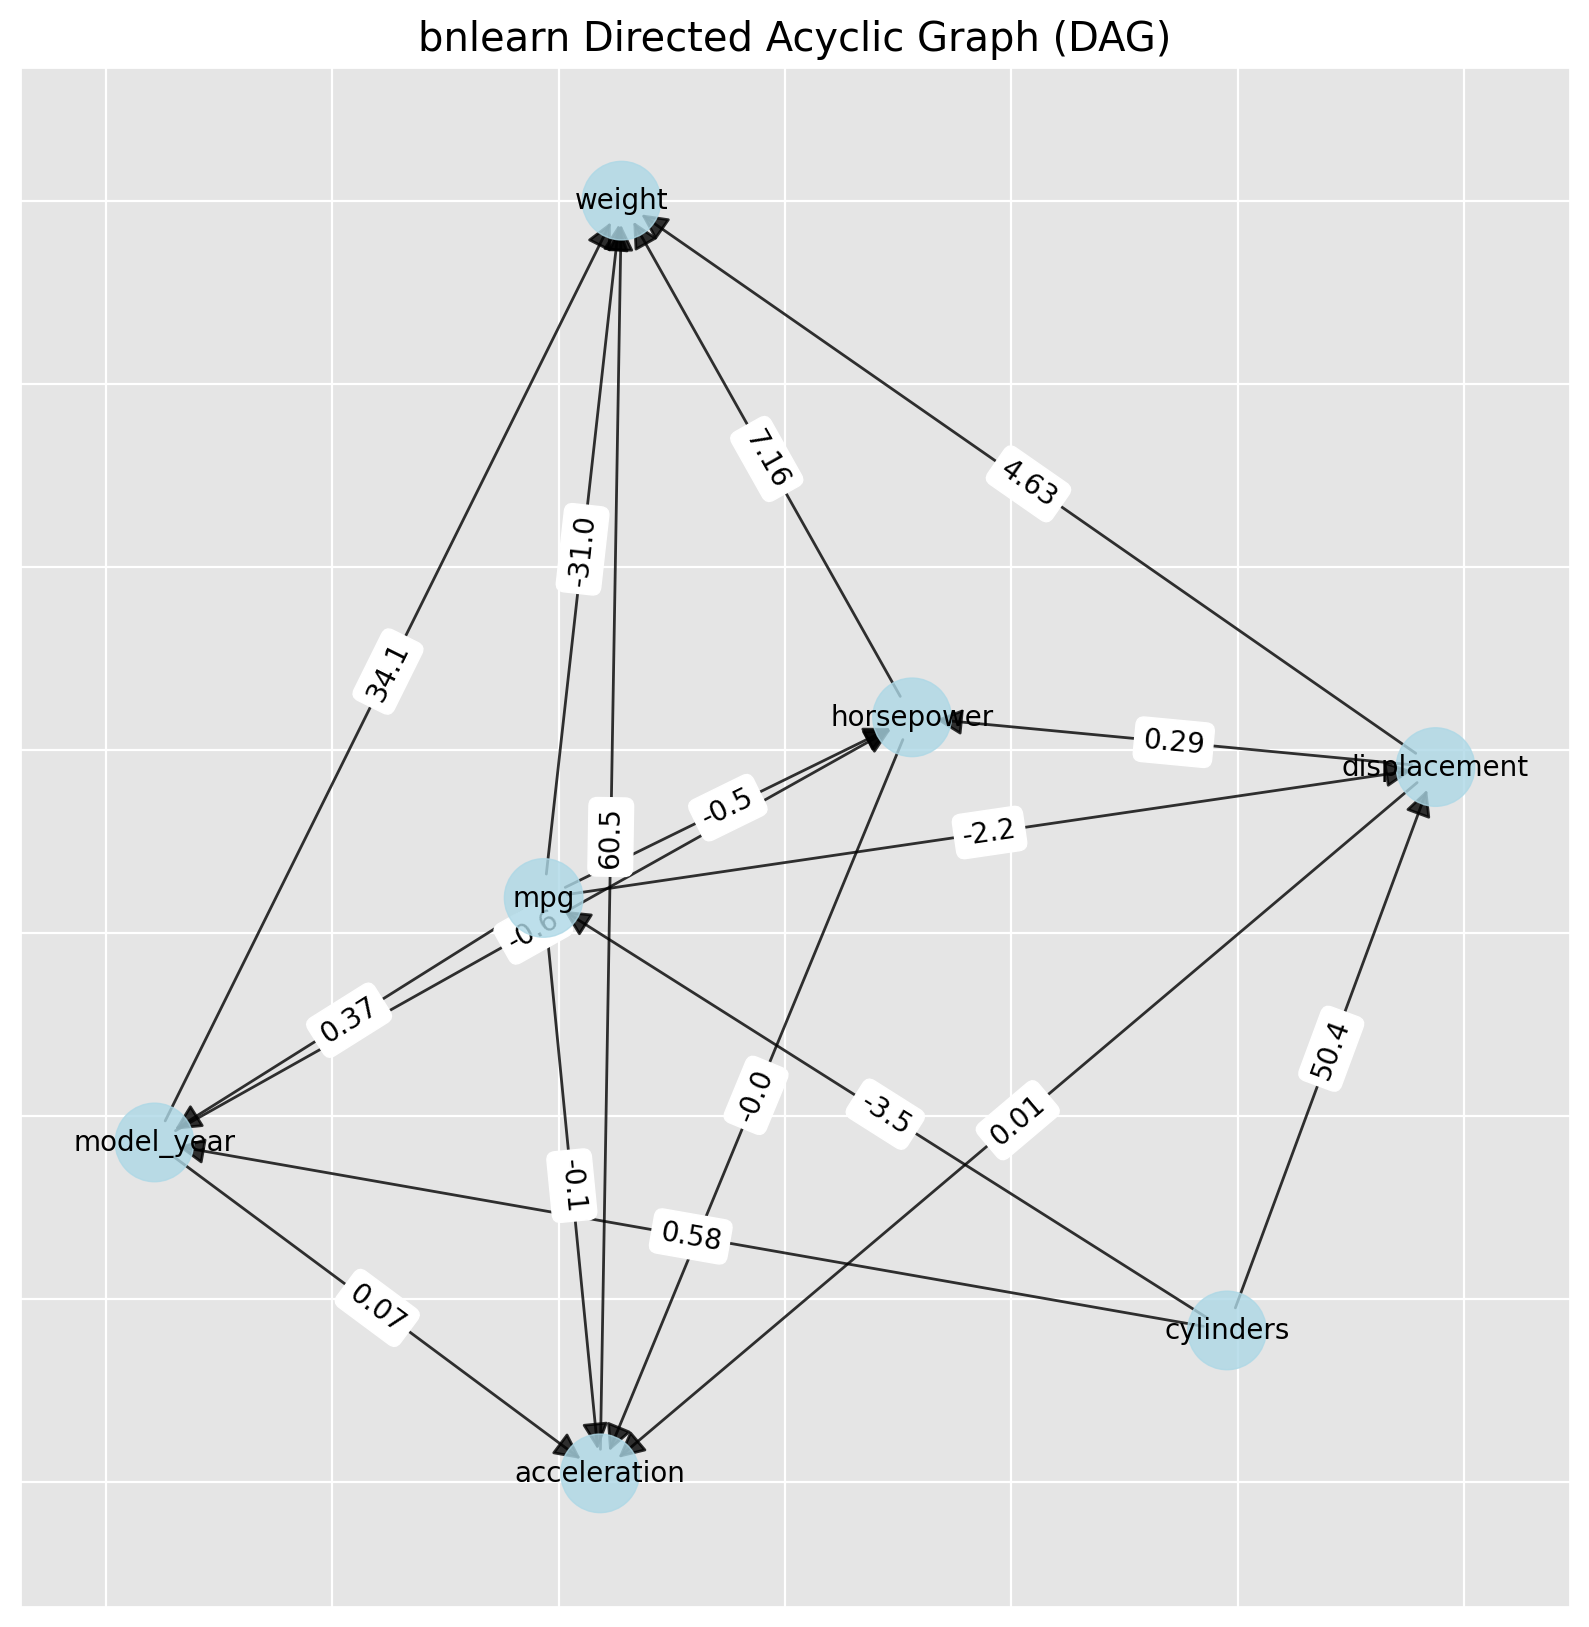

[bnlearn] >Compute edge strength with direct-lingam
[bnlearn] >30 edges are removed with P-value > 0.05 based on direct-lingam
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [dof] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


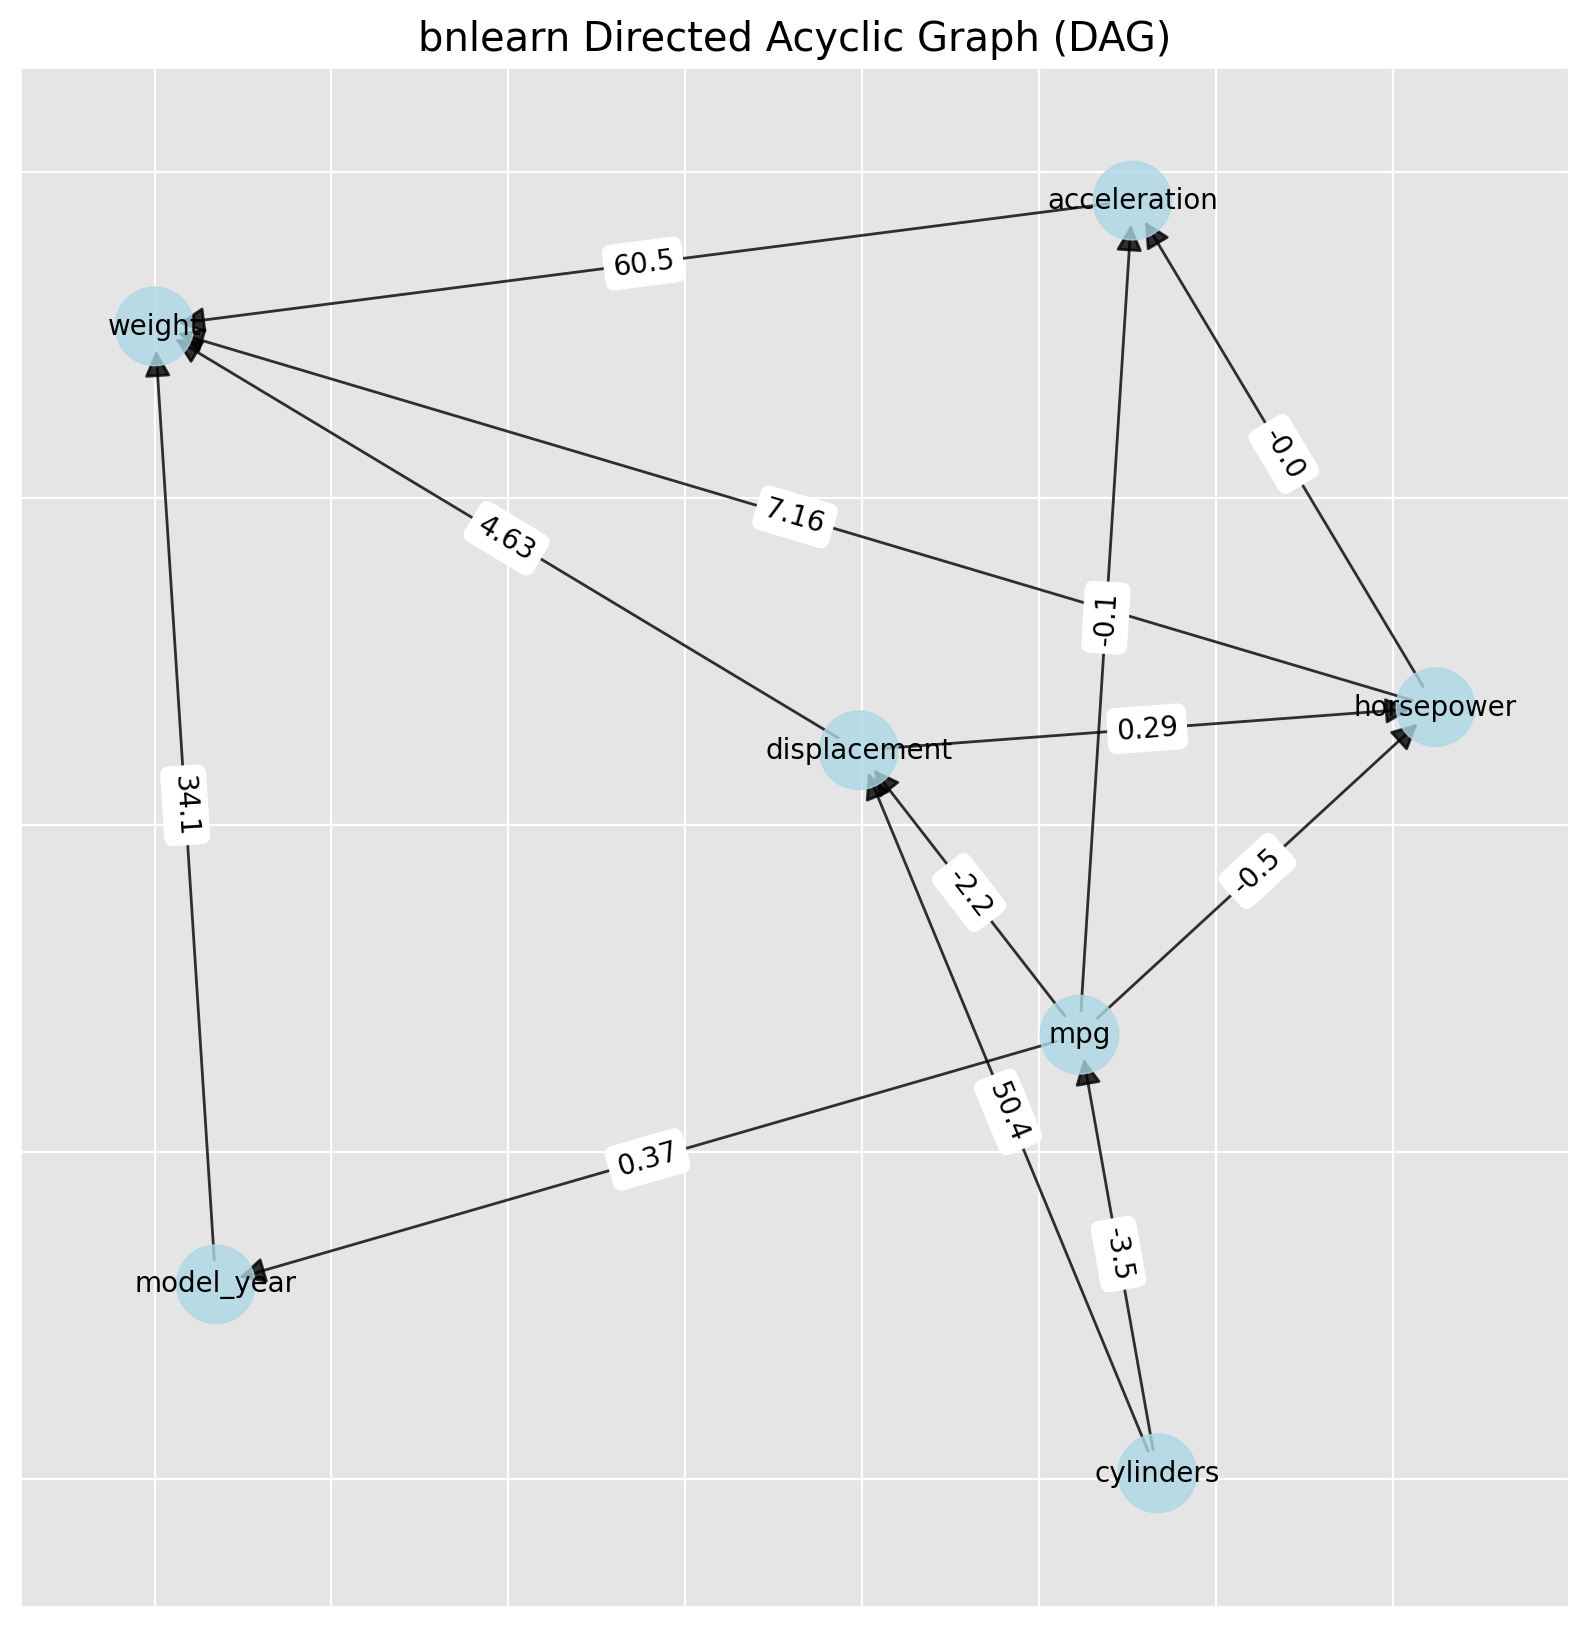

[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [dof] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


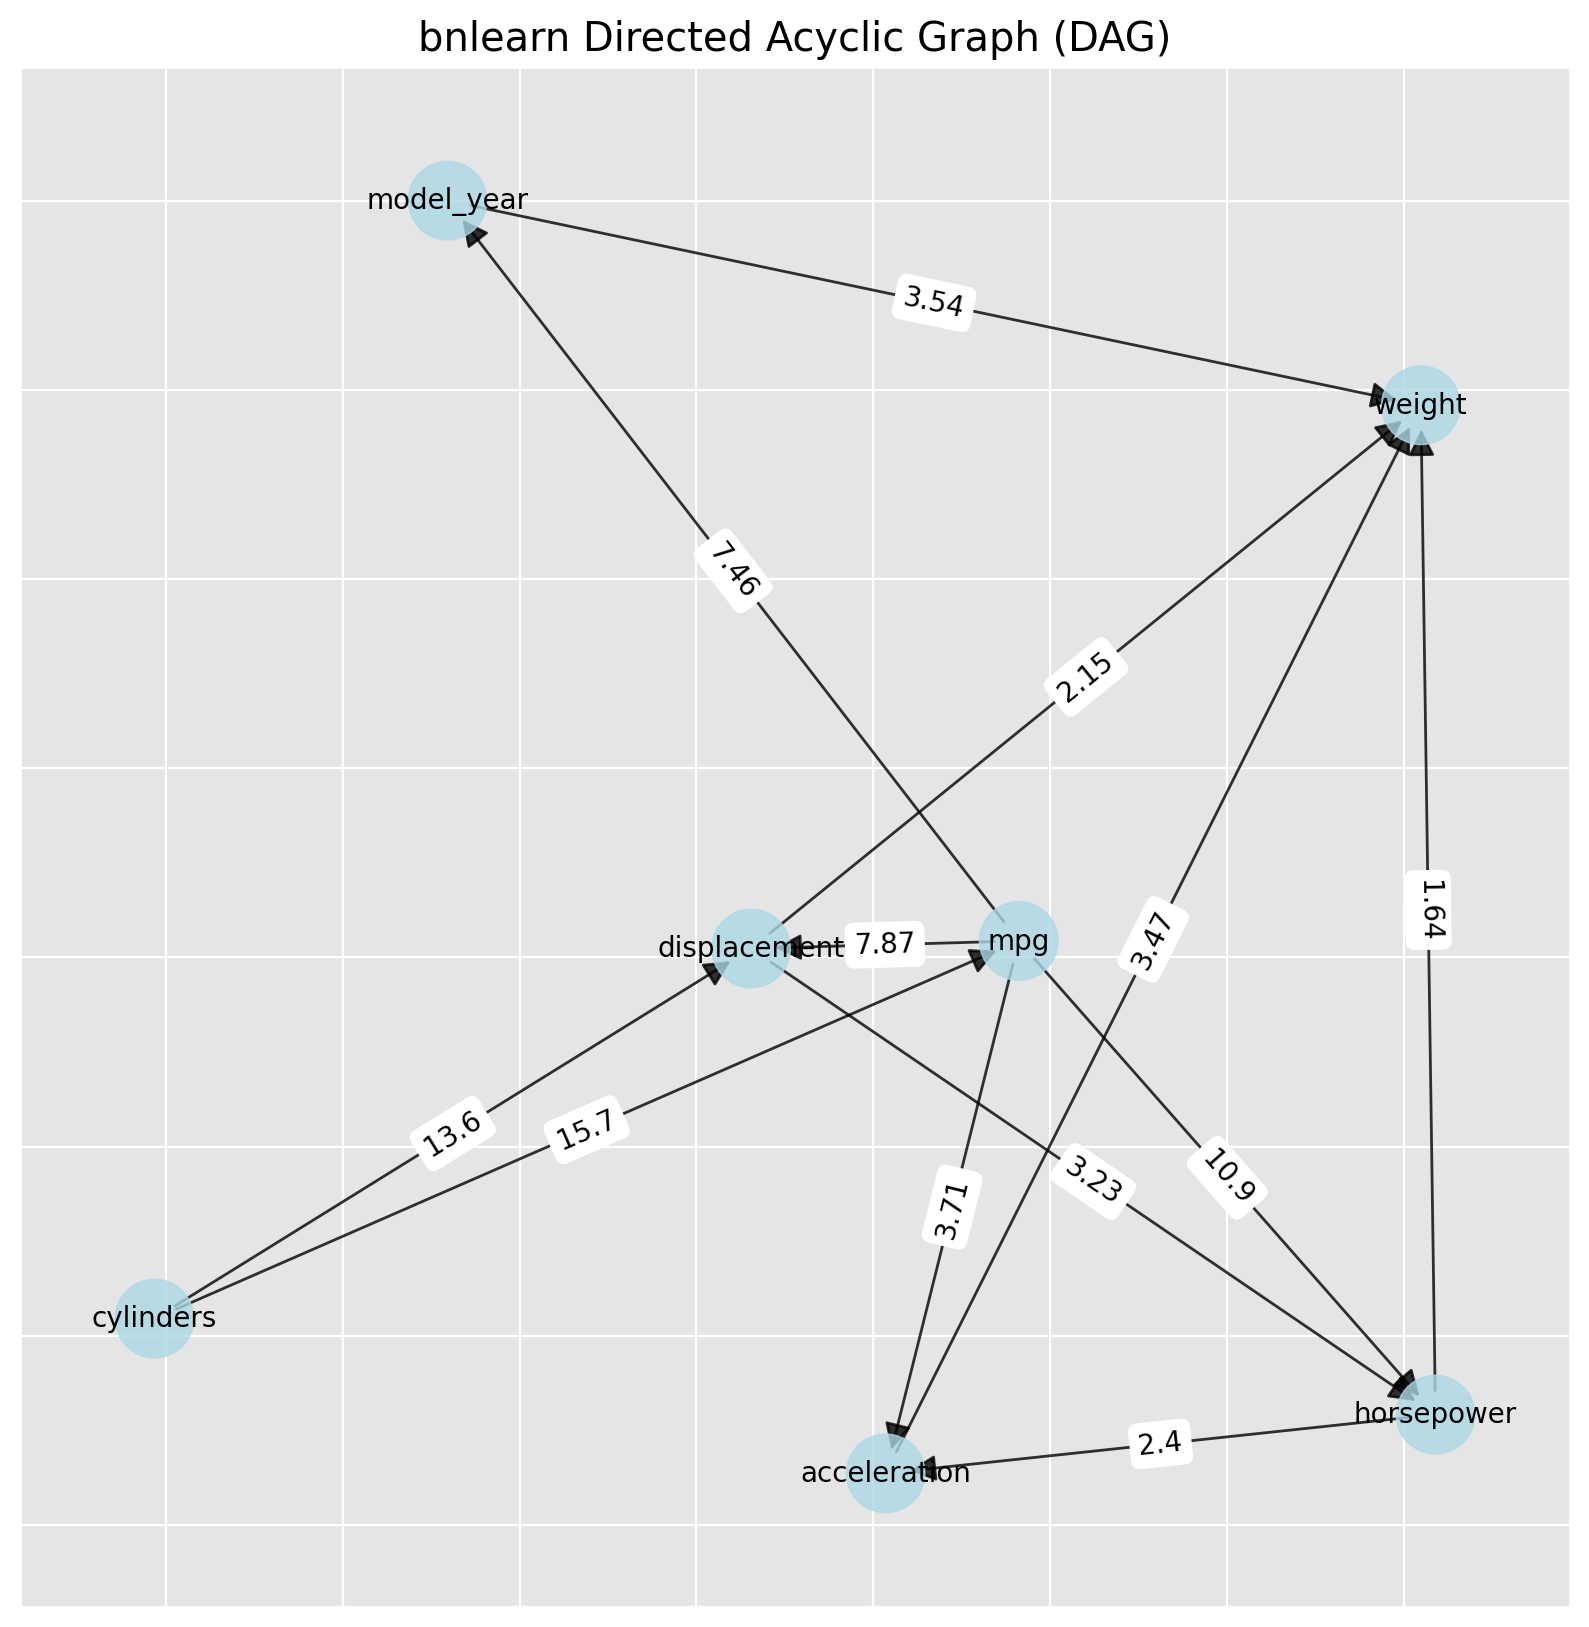

INFO:d3blocks.d3blocks:Cleaning edge_properties and config parameters..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Set directed=True to see the markers!
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Converting adjacency matrix into source-target..
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[08-02-2026 13:03:08] [d3graph.d3graph] [INFO] Slider range is set to [0, 1]


[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [dof] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.


[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Write to path: [/tmp/d3graph/d3graph.html]
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [/tmp/d3graph/d3graph.html]
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Slider range is set to [0, 1]
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] Write to path: [/tmp/d3graph/bnlearn_Directed_Acyclic_Graph_(DAG).html]
[08-02-2026 13:03:09] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [/tmp/d3graph/bnlearn_Directed_Acyclic_Graph_(DAG).html]
[08-02-2026 13:03:09] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the sys

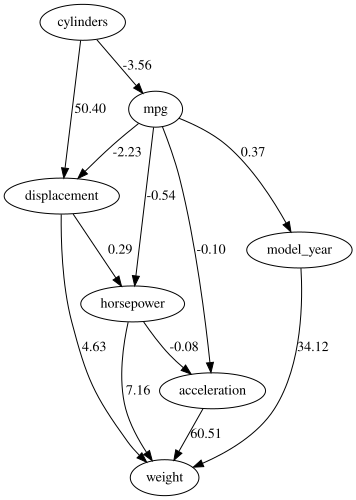

[08-02-2026 13:03:09] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:03:09] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 13:03:09] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 13:03:09] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


[bnlearn] >Setting edge labels to pvalue.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..


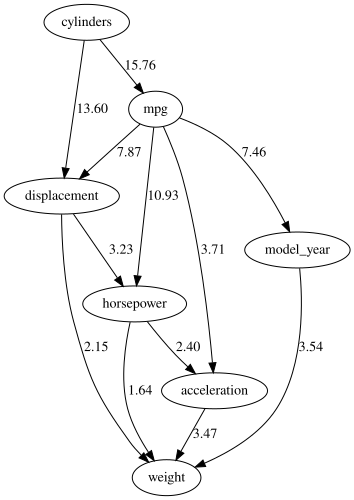

In [15]:
# Load example mixed dataset
df = bn.import_example(data='auto_mpg')
del df['origin']

# Structure learning or causal discovery
model = bn.structure_learning.fit(df, methodtype='direct-lingam', params_lingam = {'random_state': 2})

# Make plot
bn.plot(model)

# Compute edge strength with the chi_square test statistic
model = bn.independence_test(model, df, prune=True)

############
# Plotting #
############
bn.plot(model)
bn.plot(model, edge_labels='pvalue');

# Create interactive plot
bn.plot(model, interactive=True)

# Create graphviz plot
dotgraph = bn.plot_graphviz(model)

# Create pdf
dotgraph.view(filename='auto_mpg_bnlearn')

display(dotgraph)

# Create graphviz plot with Pvalue on the edges
dotgraph2 = bn.plot_graphviz(model, edge_labels='pvalue')
display(dotgraph2)